![](https://upload.wikimedia.org/wikipedia/en/6/65/Titanic_Colourised%2C_photographed_in_Southampton.png)

# 1. Import

In [1]:
# System
import os
import sys

# Numerical
import numpy as np
from numpy import median
import pandas as pd


# NLP
import re
from string import ascii_letters


# Tools
import itertools

# Machine Learning - Preprocessing
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler


# Machine Learning - Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV


# Machine Learning - Models
from sklearn import svm
from sklearn.svm import SVC
from sklearn.svm import LinearSVC, NuSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomTreesEmbedding, RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB 
from sklearn.neighbors import KDTree, KNeighborsClassifier, NearestNeighbors
from sklearn.neural_network import BernoulliRBM, MLPClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.mixture import GaussianMixture


# Machine Learning - Evaluation
from sklearn import metrics 
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from sklearn.utils import class_weight


# Plot
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns

print(os.listdir("../input"))


['train.csv', 'gender_submission.csv', 'test.csv']


# 2. Read Data

In [2]:
# import train 7 test data
train = pd.read_csv("../input/train.csv")
test = pd.read_csv("../input/test.csv")
submission = pd.read_csv("../input/gender_submission.csv")

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB


# 3. Visualization

In [6]:
df = train
columns = df.columns

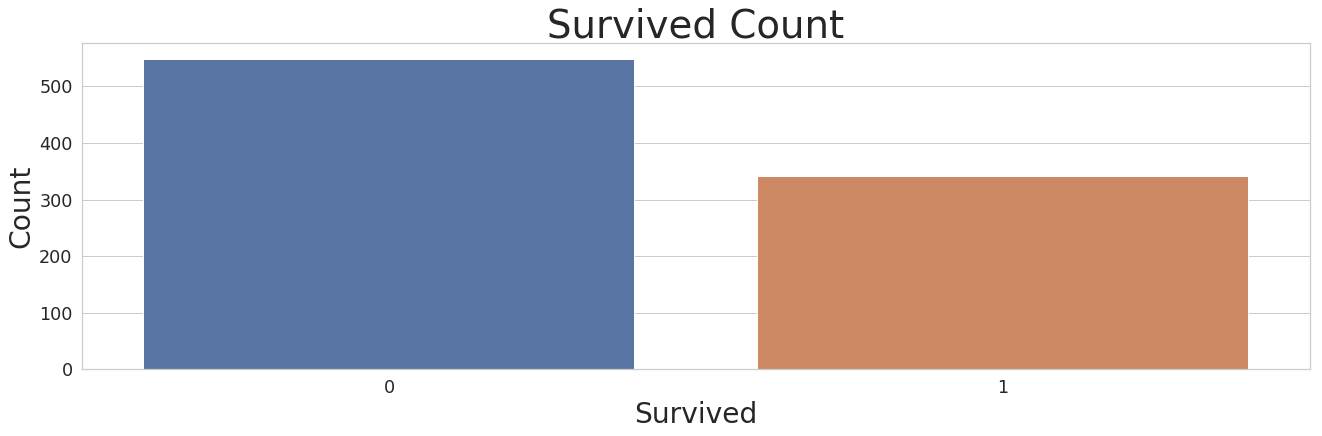

In [7]:
target = "Survived"
y_label = "Count"


nrows = 6
ncols = 22

labelsize = ncols*0.8
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.set(style="whitegrid")
sns.set_context("notebook")

ax = sns.countplot(x=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(target + " Count", fontsize=titlesize)
ax.set_xlabel(target, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

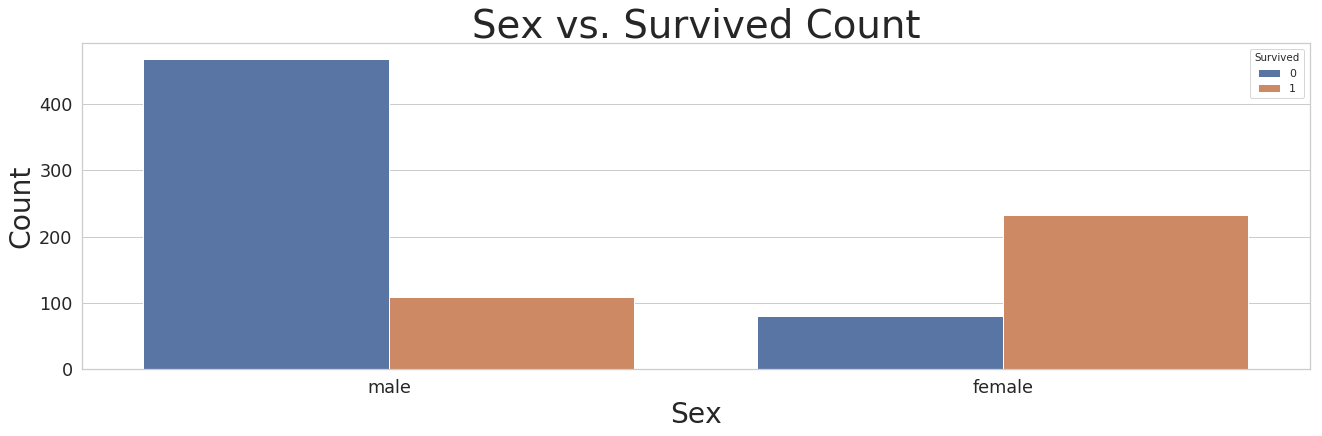

In [8]:
col = "Sex"
target = "Survived"
y_label = "Count"


nrows = 6
ncols = 22

labelsize = ncols*0.8
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.set(style="whitegrid")
sns.set_context("notebook")

ax = sns.countplot(x=col, hue=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+target +" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

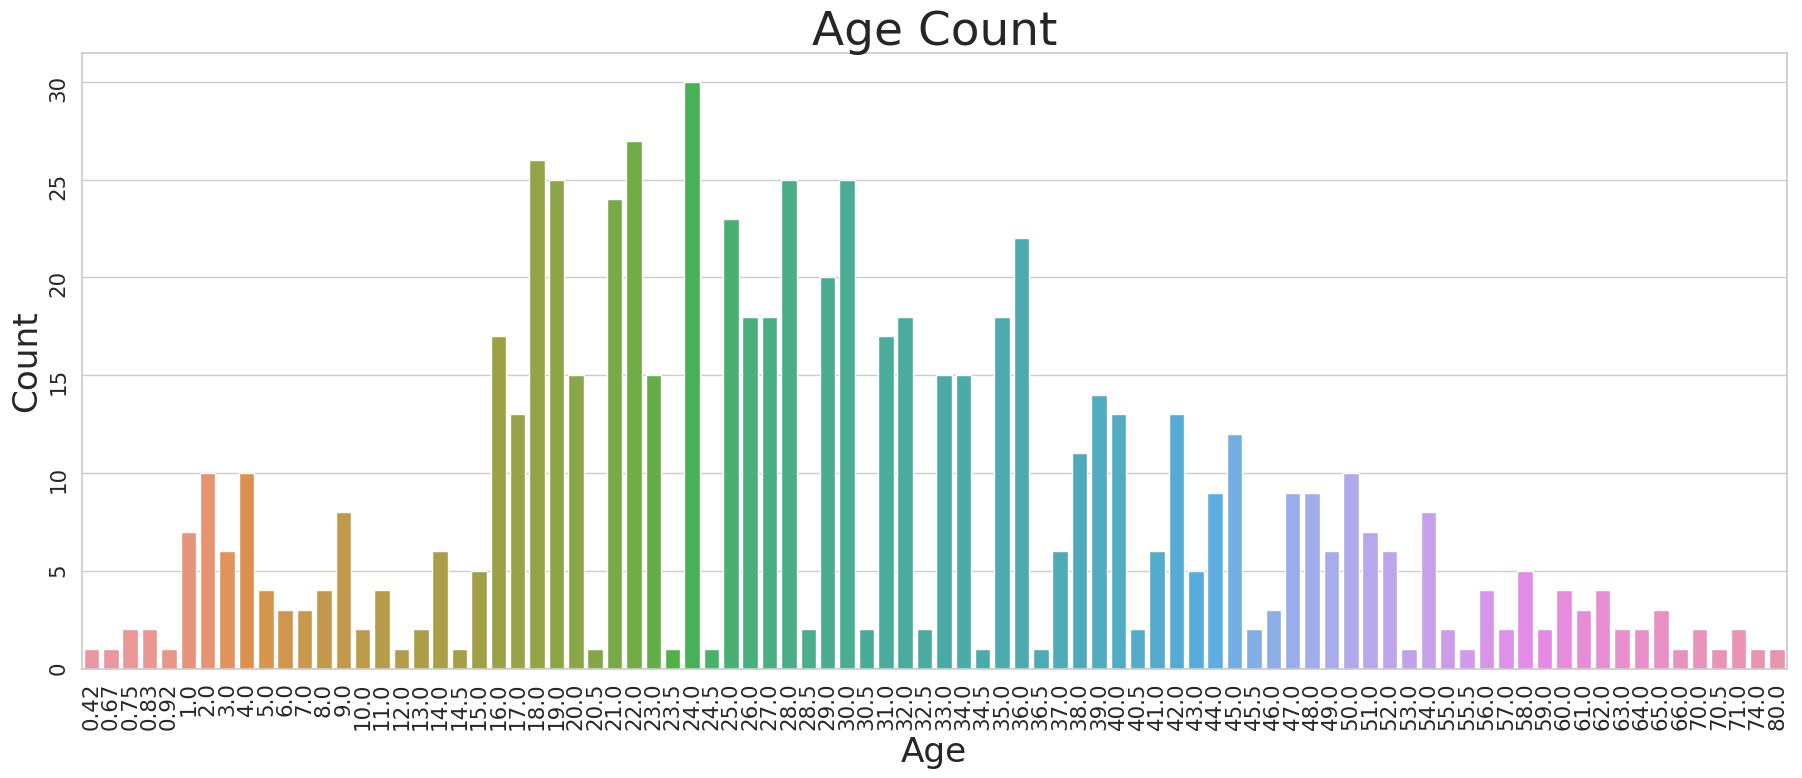

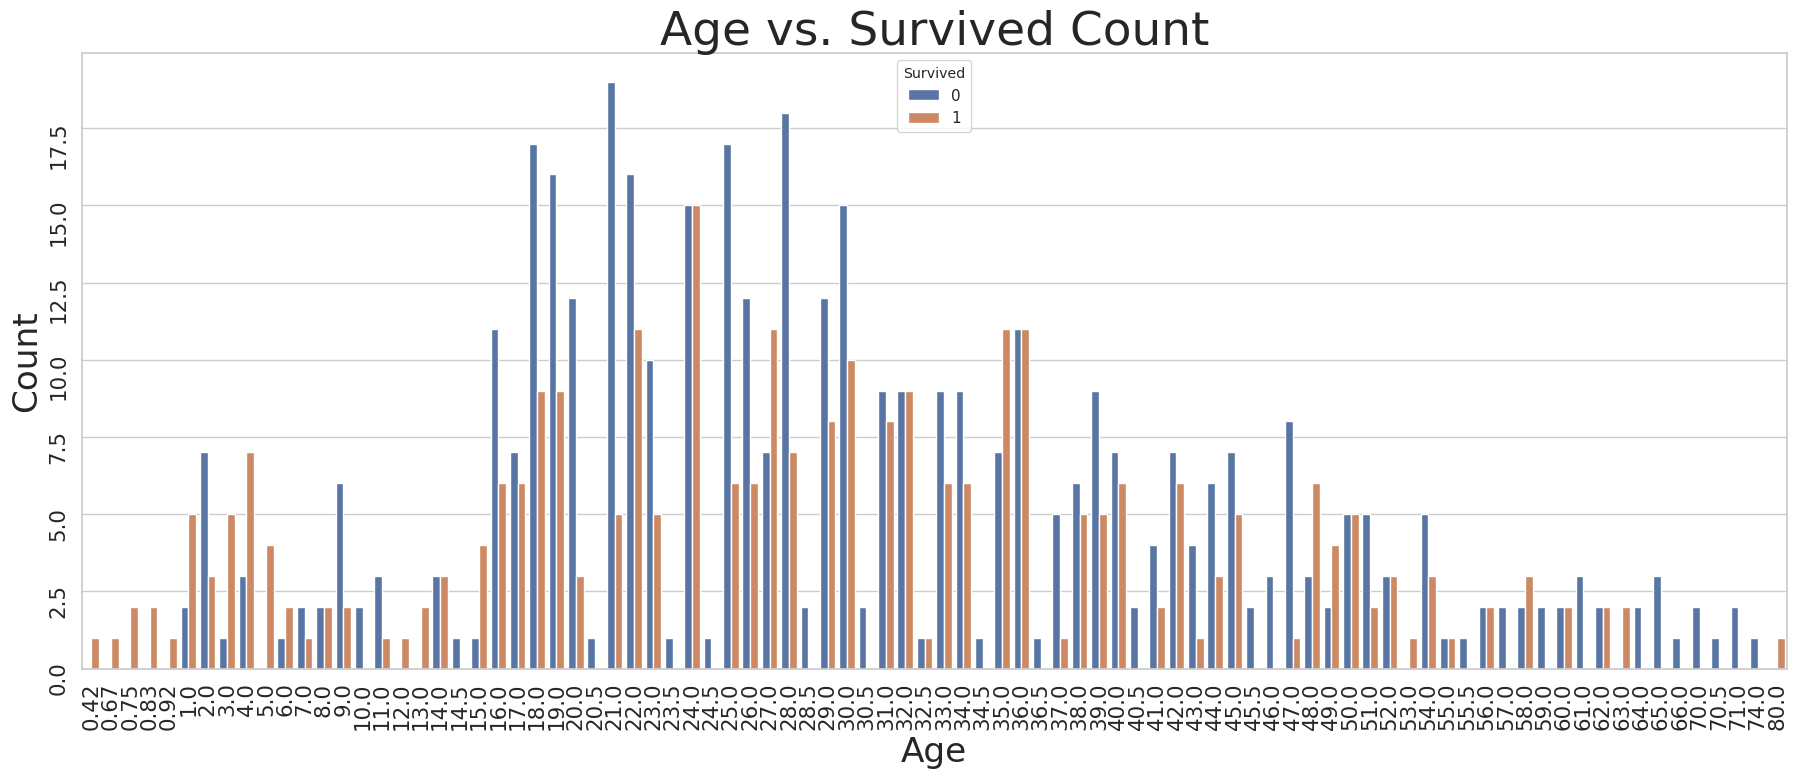

In [9]:
col = "Age"
target = "Survived"
y_label = "Count"

nrows = 8
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

ax = sns.countplot(x=col, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize, rotation=90)
plt.show()

ax = sns.countplot(x=col, hue=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize, rotation=90)
plt.show()

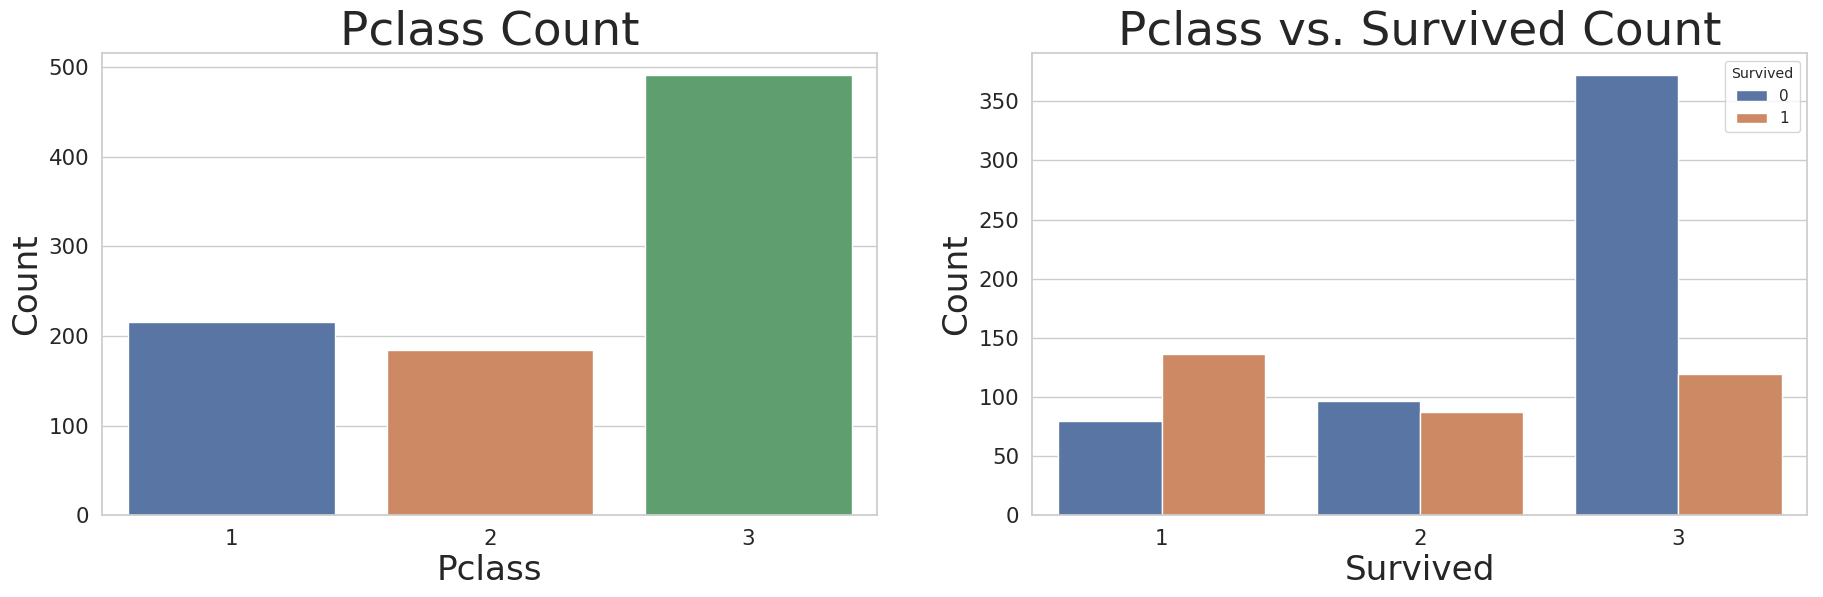

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


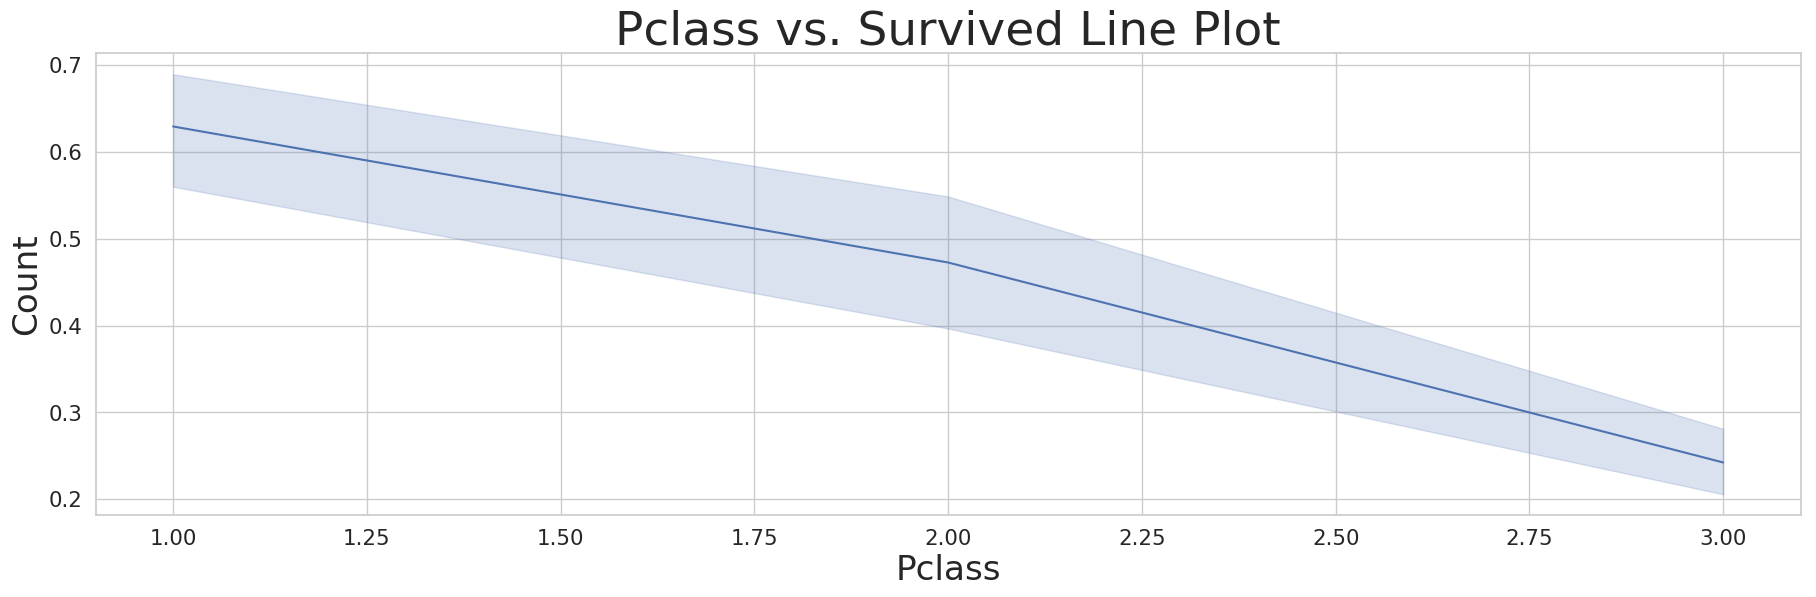

In [10]:
col = "Pclass"
target = "Survived"
y_label = "Count"

nrows = 6
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

plt.subplot(121)
ax = sns.countplot(x=col, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

plt.subplot(122)
ax = sns.countplot(x=col, hue=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Count", fontsize=titlesize)
ax.set_xlabel(target, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

ax = sns.lineplot(x=col, y=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Line Plot", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

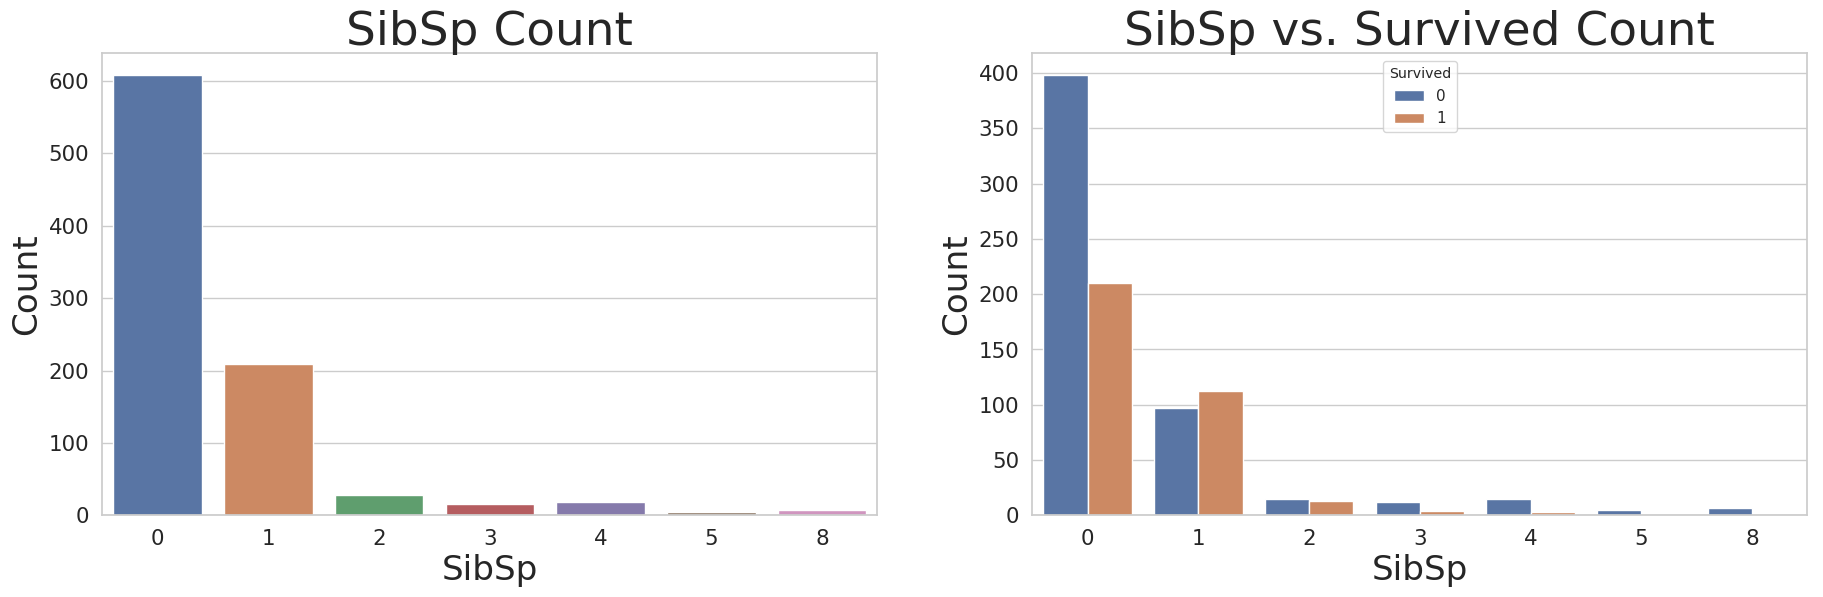

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


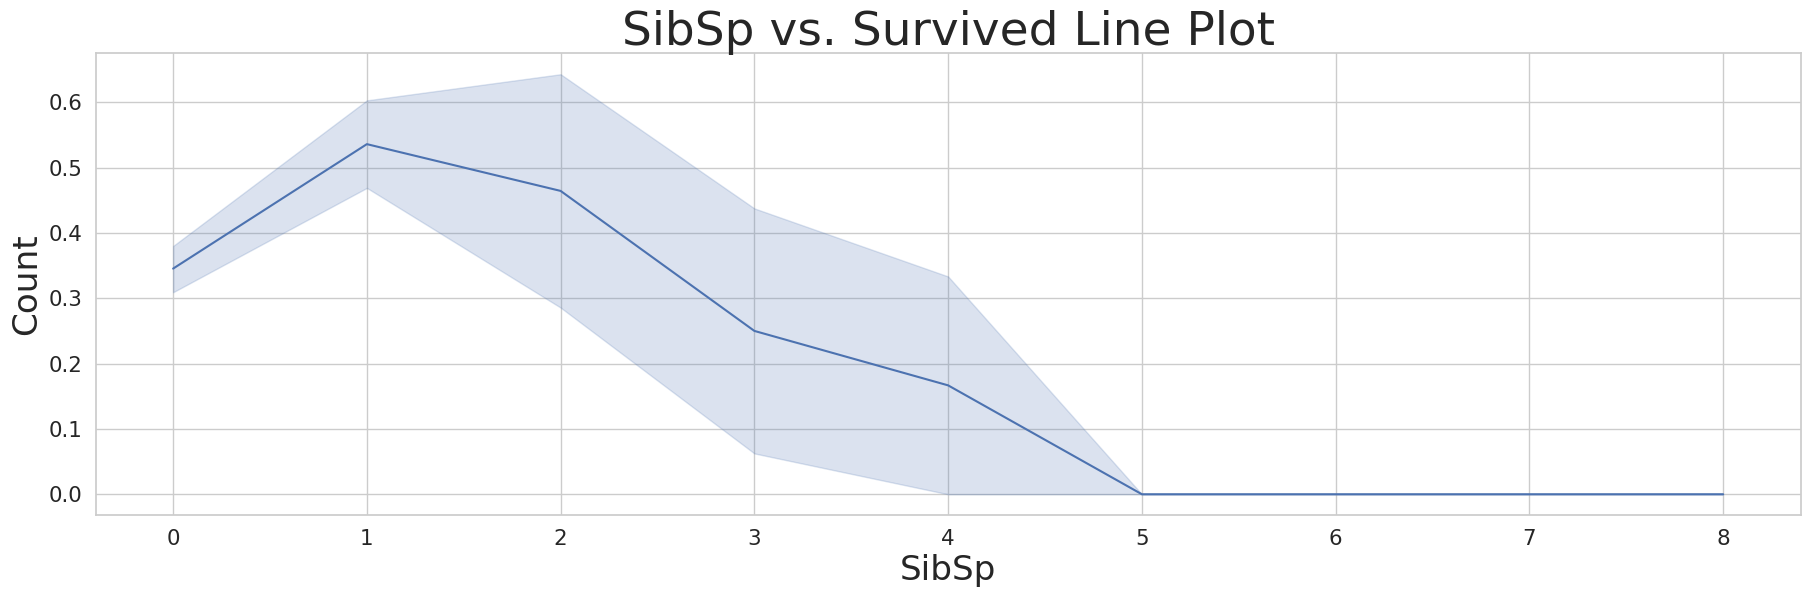

In [11]:
col = "SibSp"
target = "Survived"
y_label = "Count"


nrows = 6
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

plt.subplot(121)
ax = sns.countplot(x=col, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

plt.subplot(122)
ax = sns.countplot(x=col, hue=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()


ax = sns.lineplot(x=col, y=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Line Plot", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

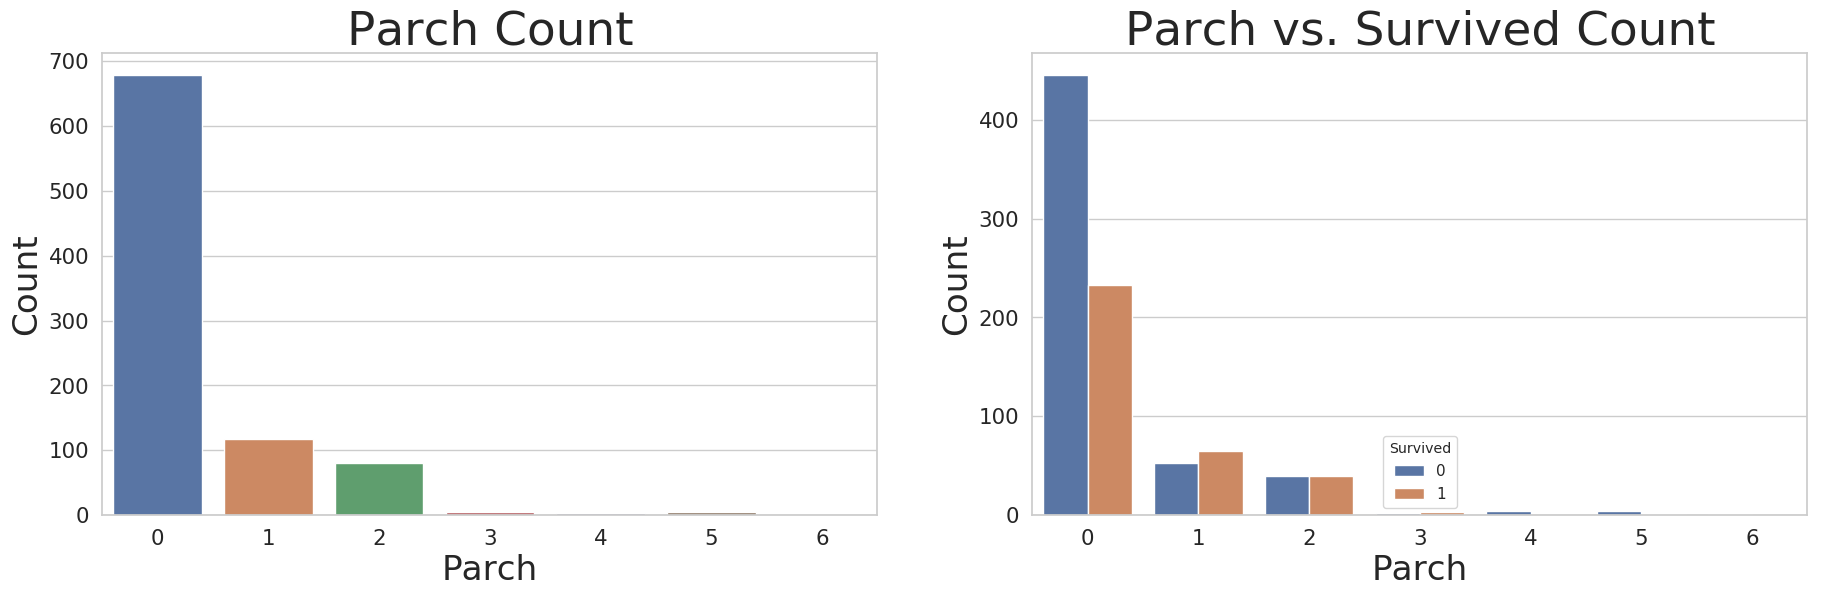

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


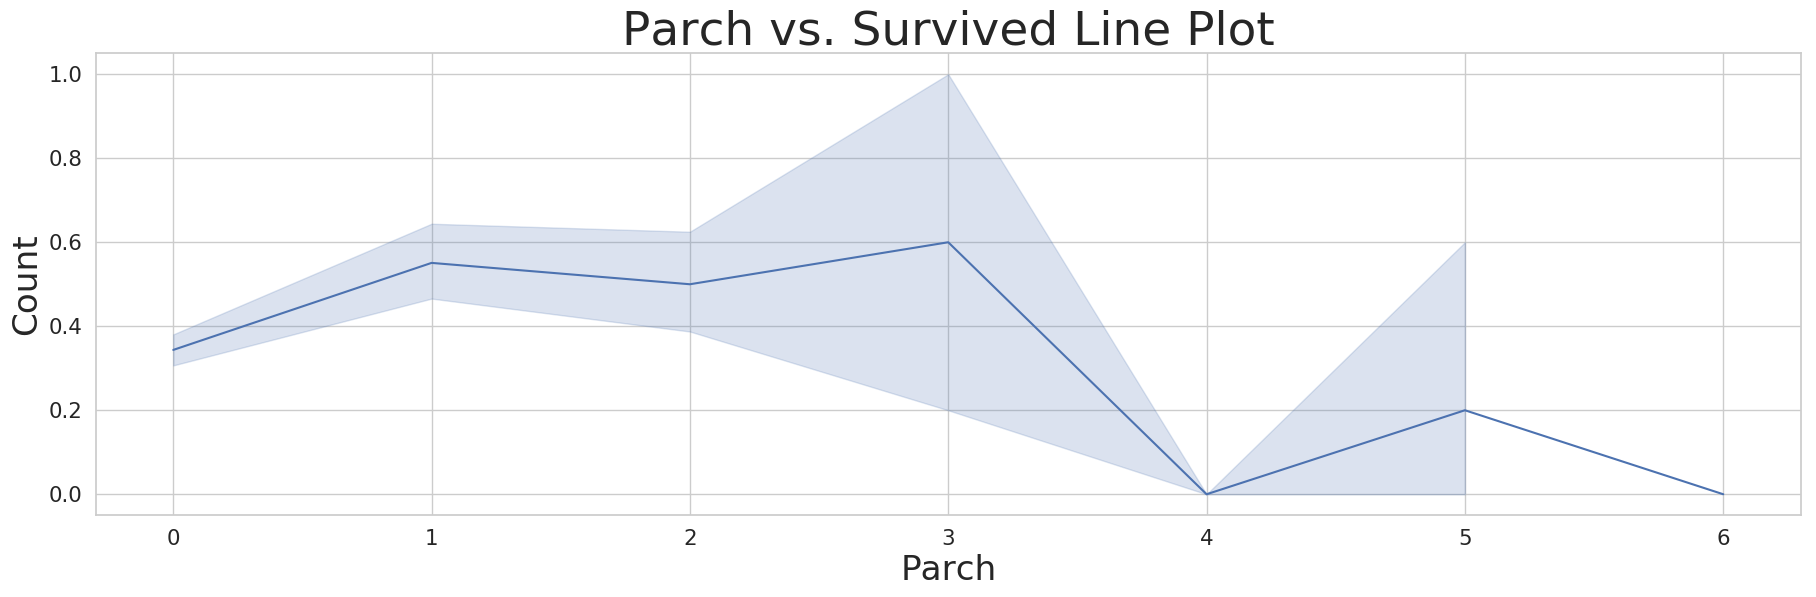

In [12]:
col = "Parch"
target = "Survived"
y_label = "Count"

nrows = 6
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

plt.subplot(121)
ax = sns.countplot(x=col, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

plt.subplot(122)
ax = sns.countplot(x=col, hue=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

ax = sns.lineplot(x=col, y=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Line Plot", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

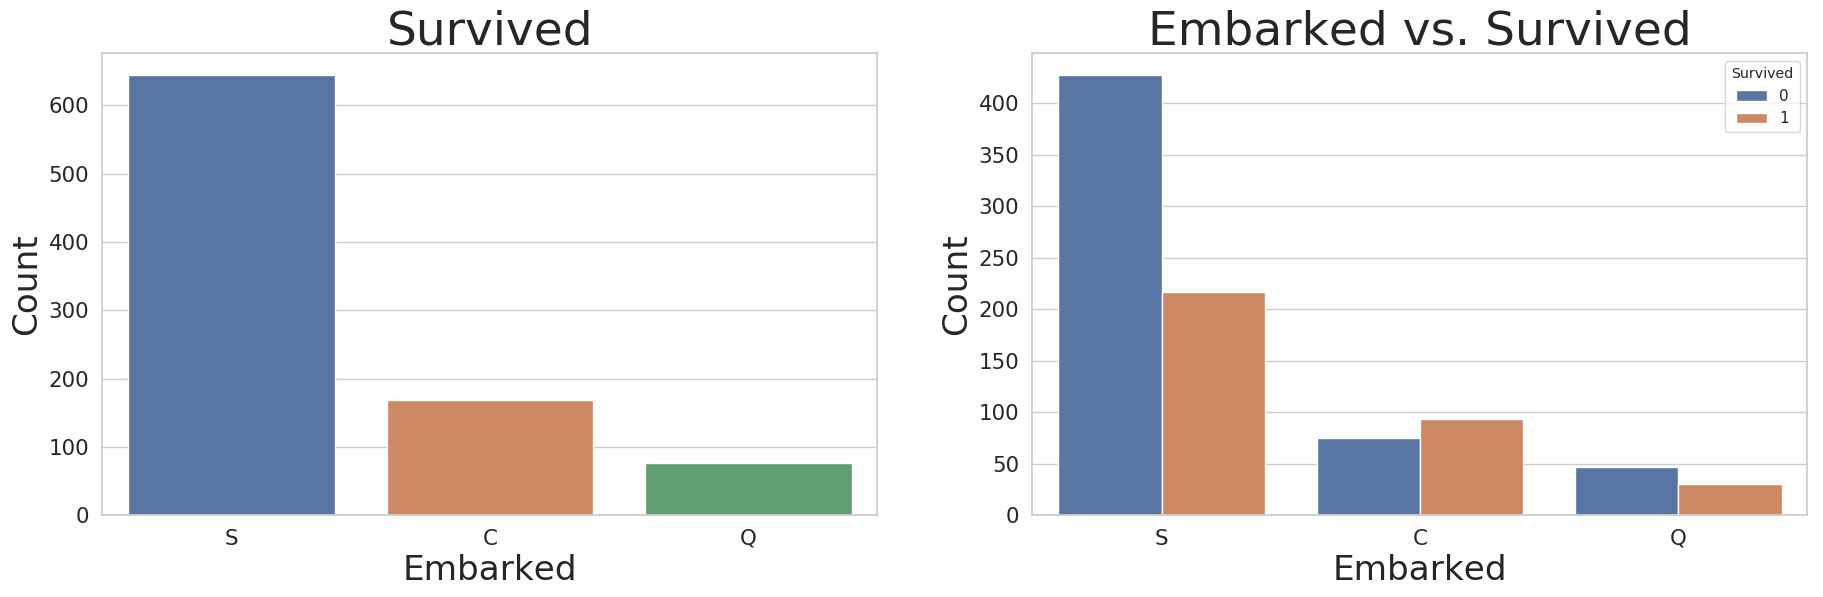

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


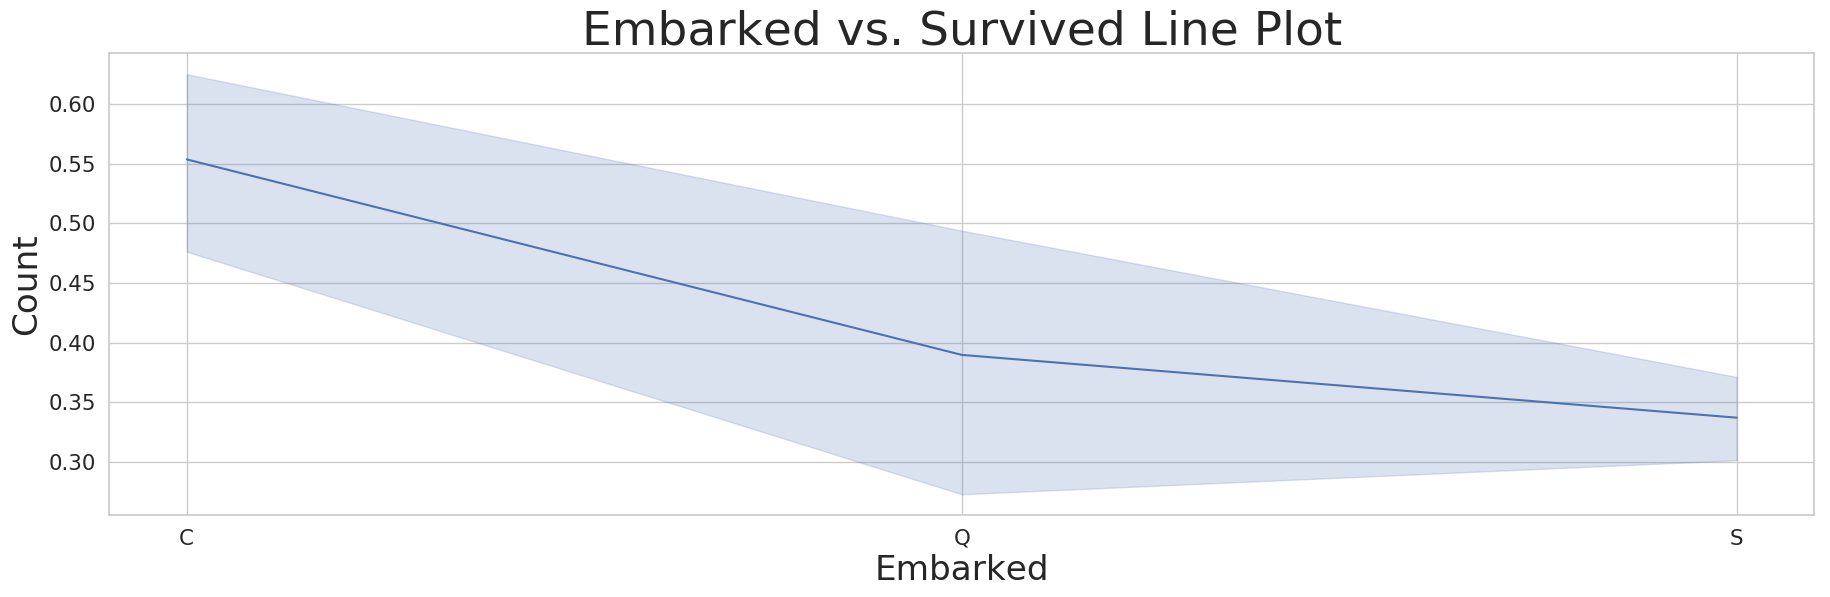

In [13]:
col = "Embarked"
target = "Survived"
y_label = "Count"



nrows = 6
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

plt.subplot(121)
ax = sns.countplot(x=col, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(target, fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

plt.subplot(122)
ax = sns.countplot(x=col, hue=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target, fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

ax = sns.lineplot(x=col, y=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Line Plot", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


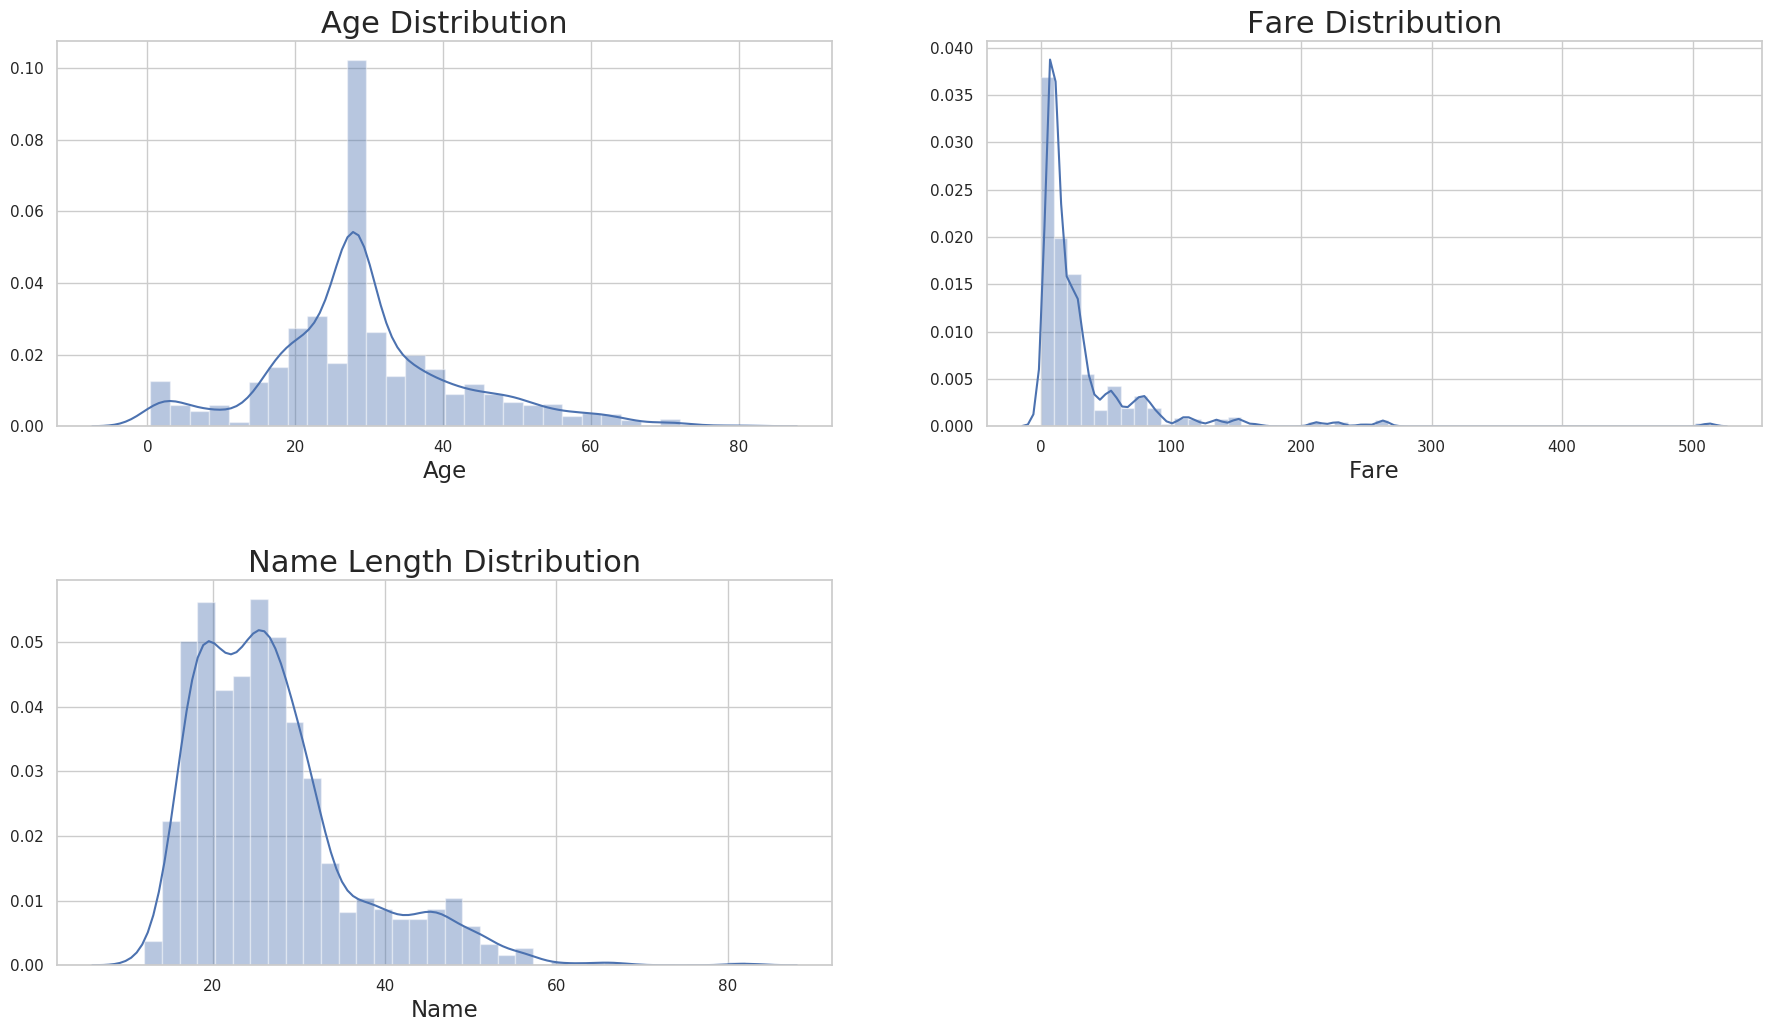

In [14]:
col1 = "Age"
col2 = "Fare"
col3 = "Name"

target = "Survived"


nrows = 12
ncols = 22

labelsize = ncols*.5
fontsize = labelsize*1.5
titlesize = labelsize*2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

plt.subplots_adjust(hspace = 0.4)

df[col1] = df[col1].fillna(df[col1].median())
plt.subplot(221)
ax = sns.distplot(df[col1])
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col1+" Distribution", fontsize=titlesize)
ax.set_xlabel(col1, fontsize=fontsize)
ax.set_ylabel("", fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

plt.subplot(222)
ax = sns.distplot(df[col2])
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col2+" Distribution", fontsize=titlesize)
ax.set_xlabel(col2, fontsize=fontsize)
ax.set_ylabel("", fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

plt.subplot(223)
ax = sns.distplot(df[col3].apply(lambda x:len(x)))
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col3+" Length"+" Distribution", fontsize=titlesize)
ax.set_xlabel(col3, fontsize=fontsize)
ax.set_ylabel("", fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

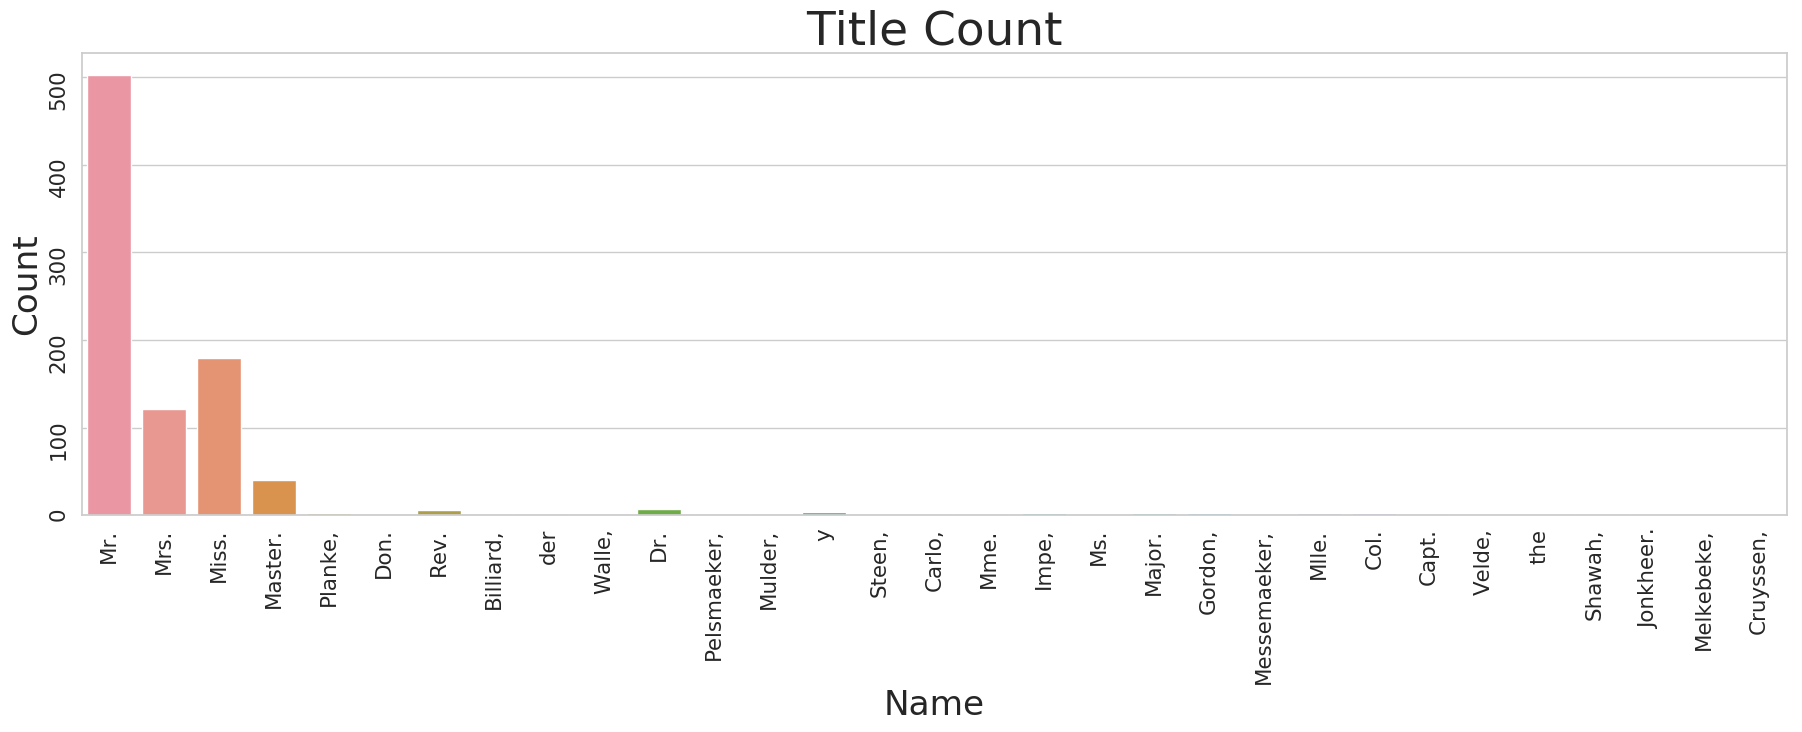

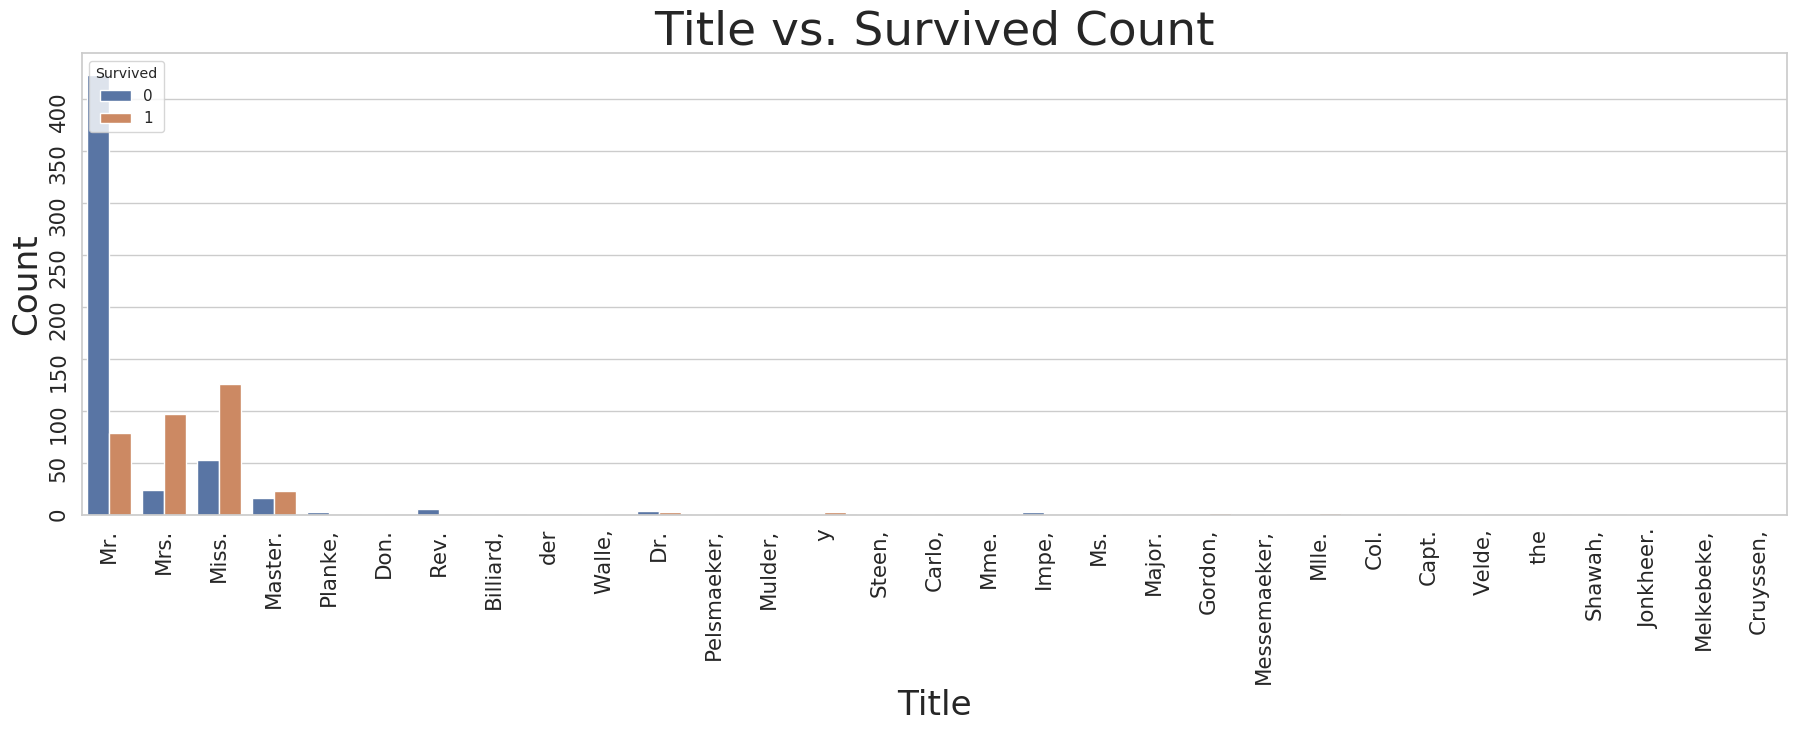

In [15]:
col1 = "Name"
col2 = "Title"
target = "Survived"
y_label = "Count"


nrows = 6
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

df[col2] = df[col1].apply(lambda x:x.split(" ")[1])
ax = sns.countplot(x=col2, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col2+" Count", fontsize=titlesize)
ax.set_xlabel(col1, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize, rotation=90)
plt.show()

ax = sns.countplot(x=col2, hue=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col2+" vs. "+ target+" Count", fontsize=titlesize)
ax.set_xlabel(col2, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize, rotation=90)
plt.show()

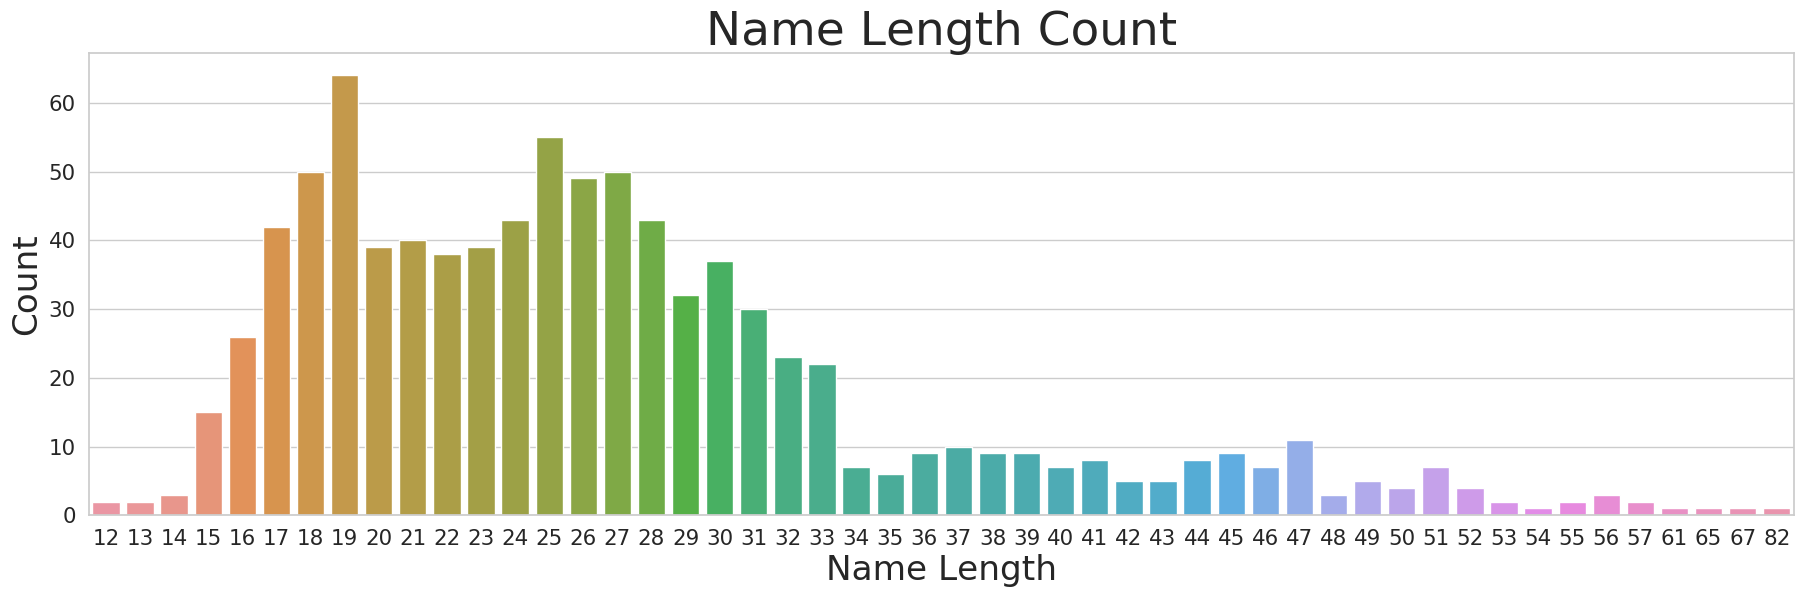

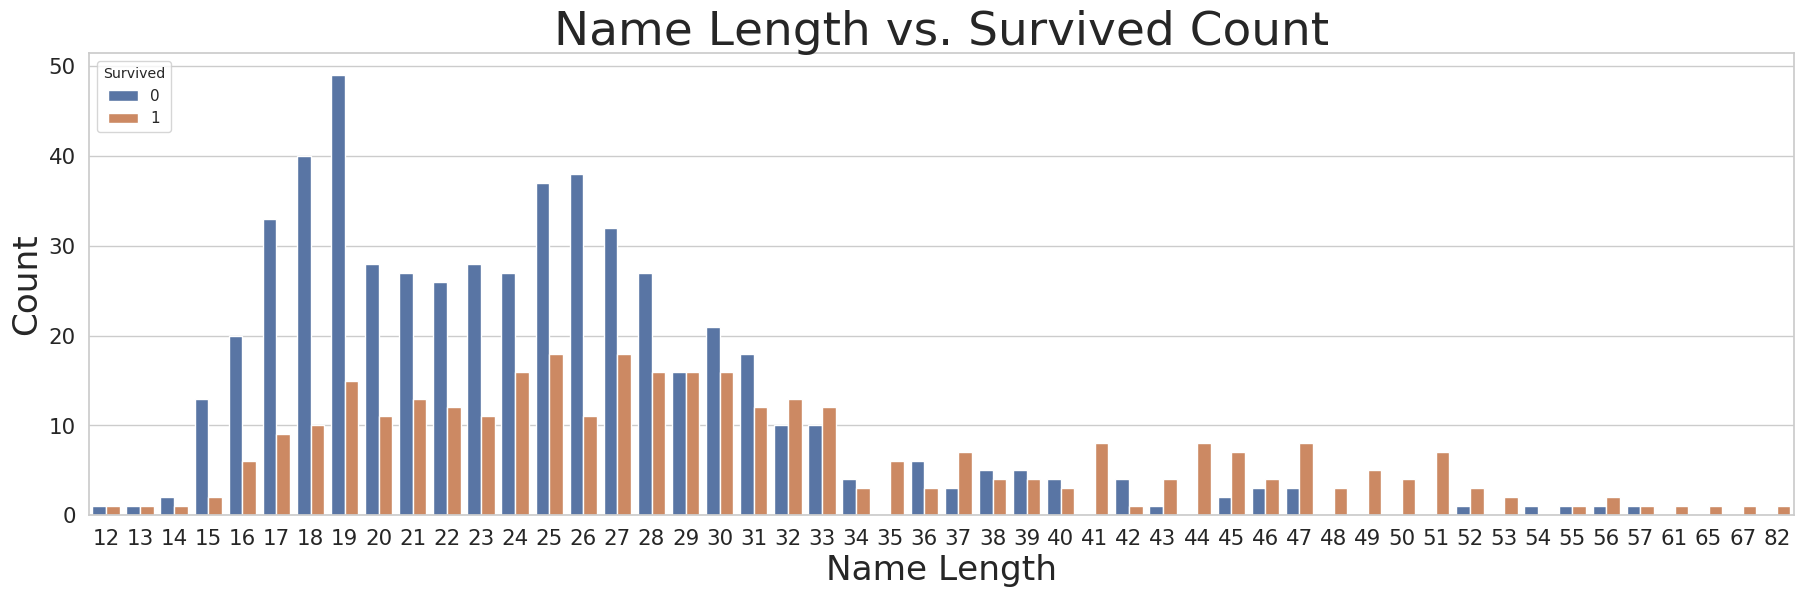

/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


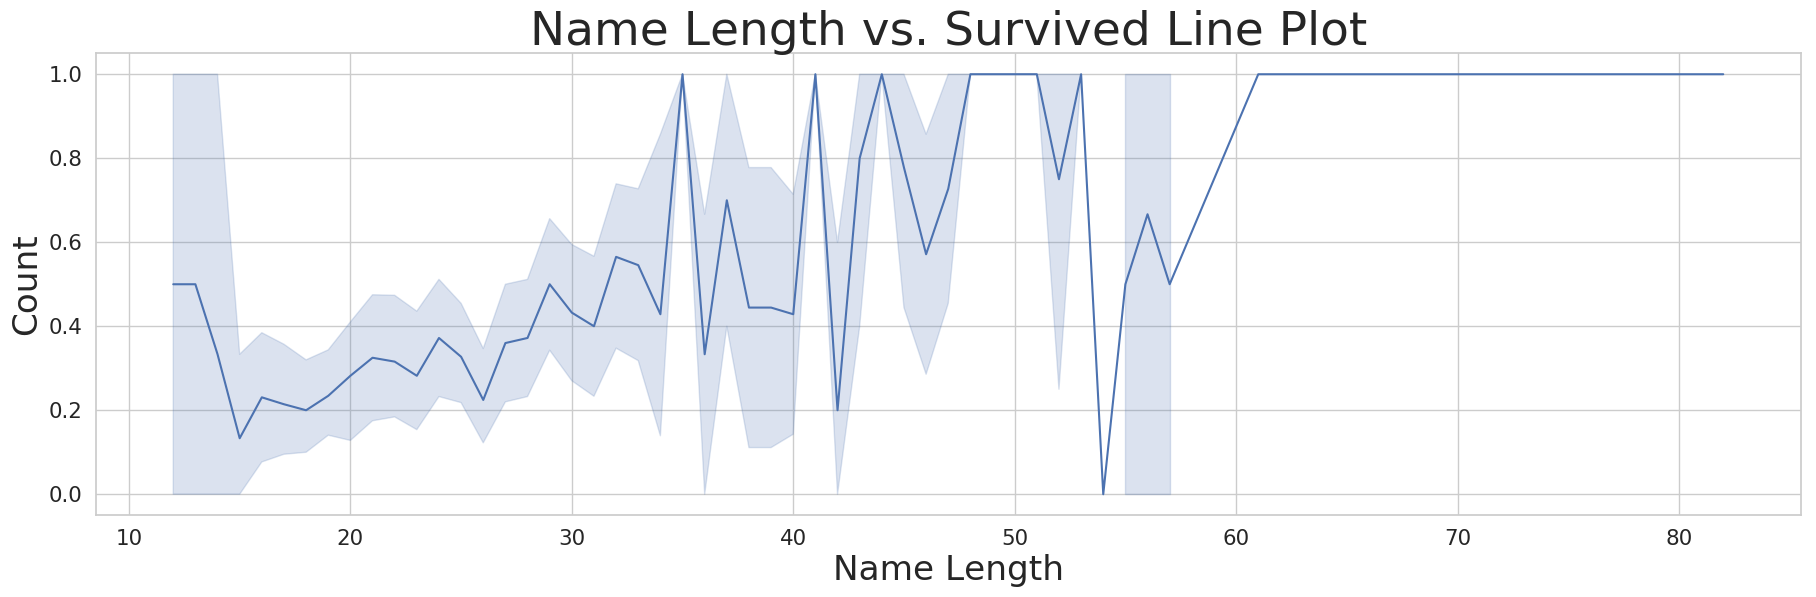

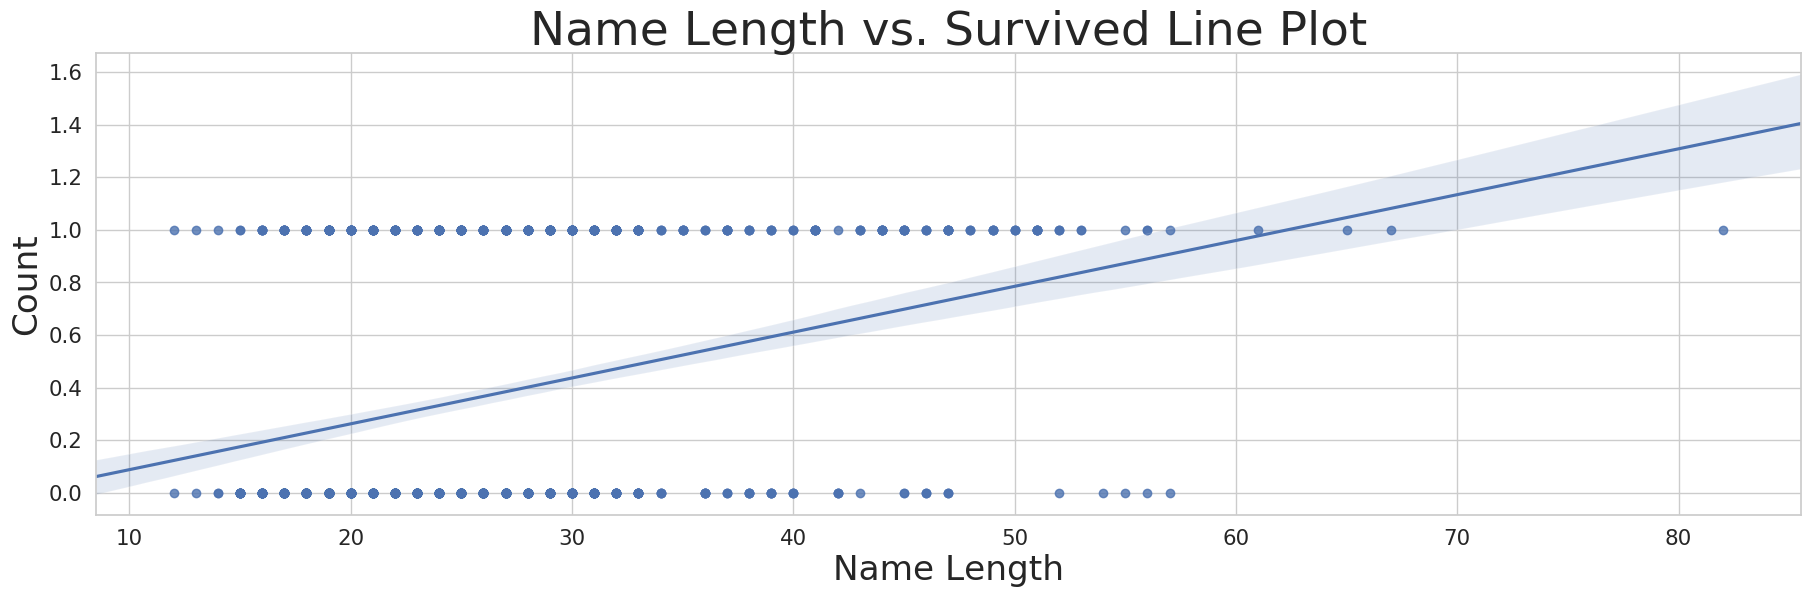

In [16]:
col1 = "Name"
col2 = "Name Length"
target = "Survived"
y_label = "Count"


nrows = 6
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

df[col2] = df[col1].apply(lambda x:len(x))
ax = sns.countplot(x=col2, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col2+" Count", fontsize=titlesize)
ax.set_xlabel(col2, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

ax = sns.countplot(x=col2, hue=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col2+" vs. "+ target+" Count", fontsize=titlesize)
ax.set_xlabel(col2, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()


ax = sns.lineplot(x=col2, y=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col2+" vs. "+ target+" Line Plot", fontsize=titlesize)
ax.set_xlabel(col2, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

ax = sns.regplot(x=col2, y=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col2+" vs. "+ target+" Line Plot", fontsize=titlesize)
ax.set_xlabel(col2, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()


/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


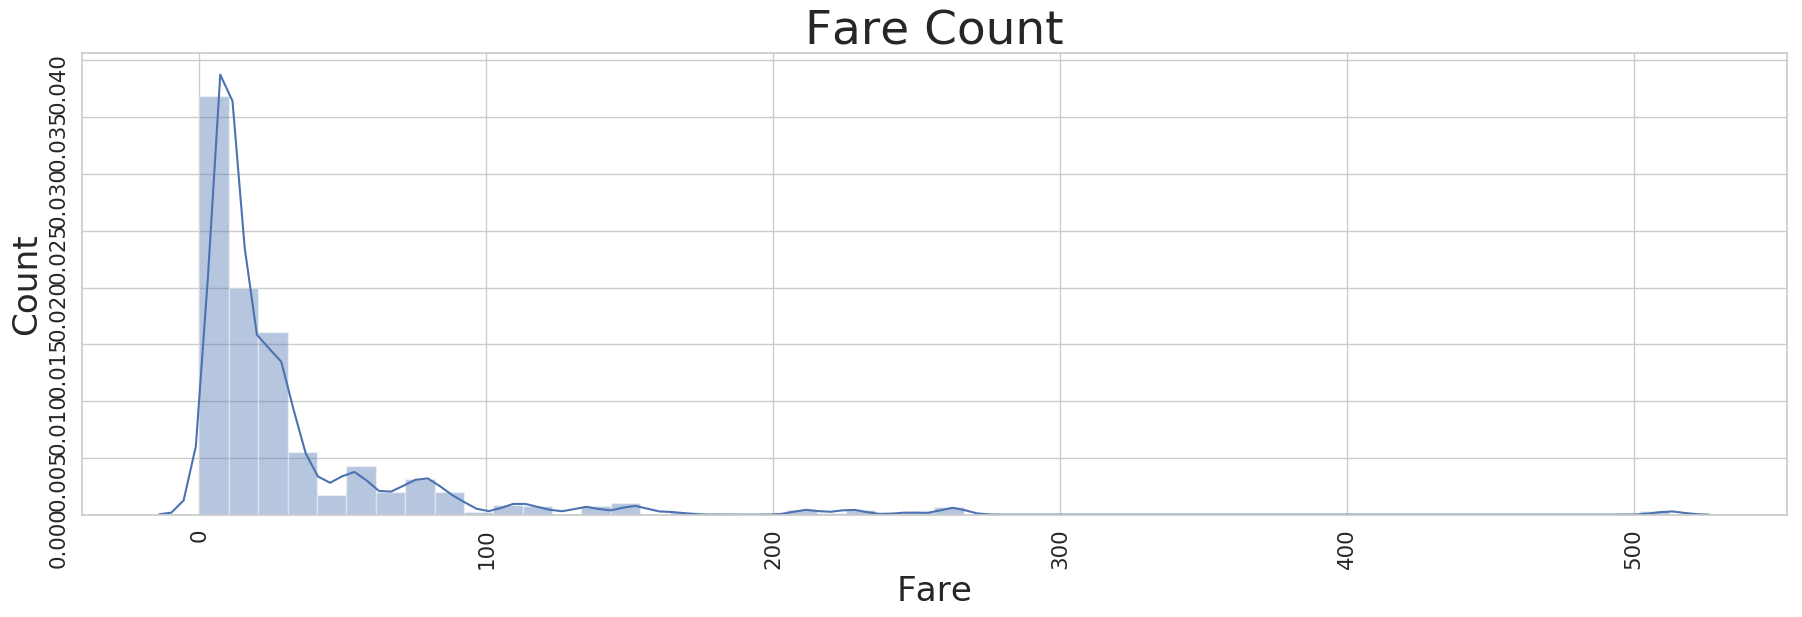

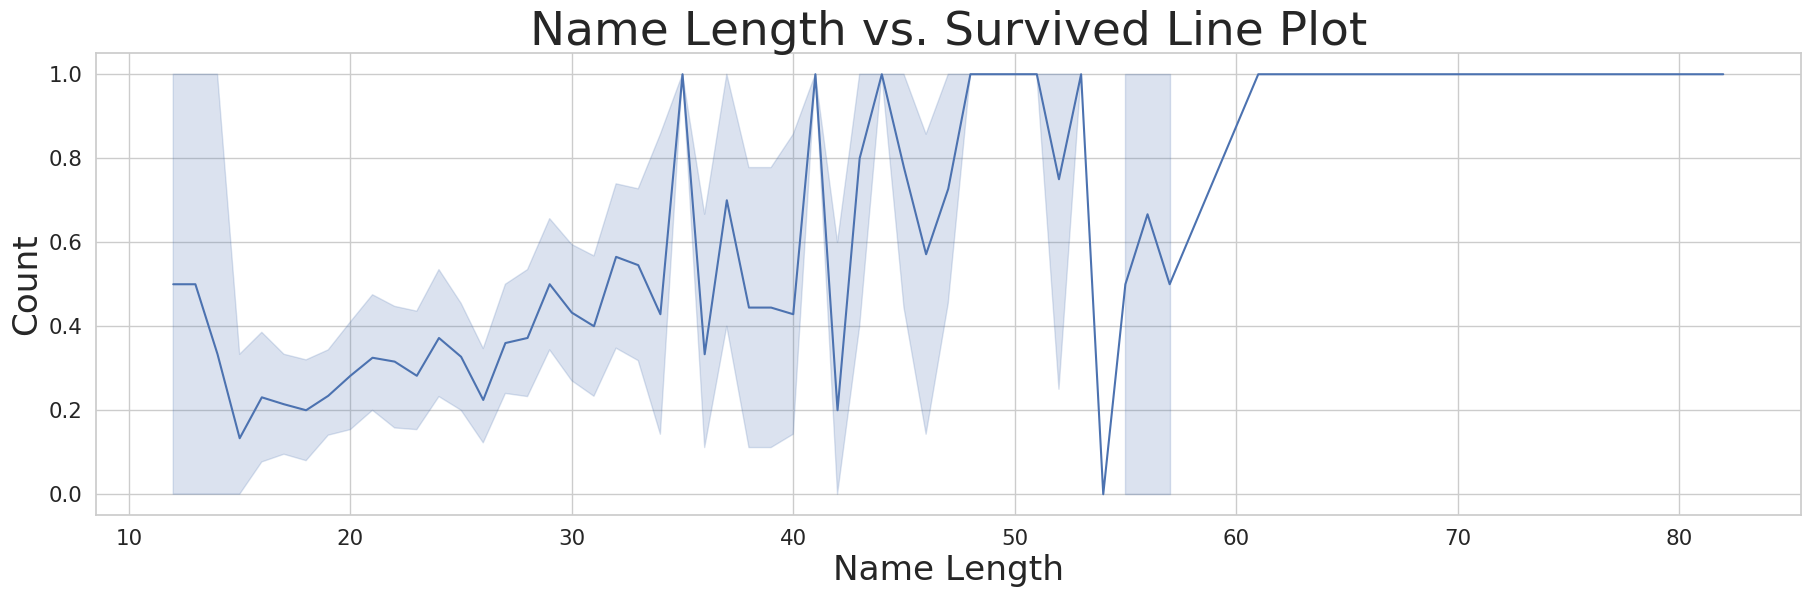

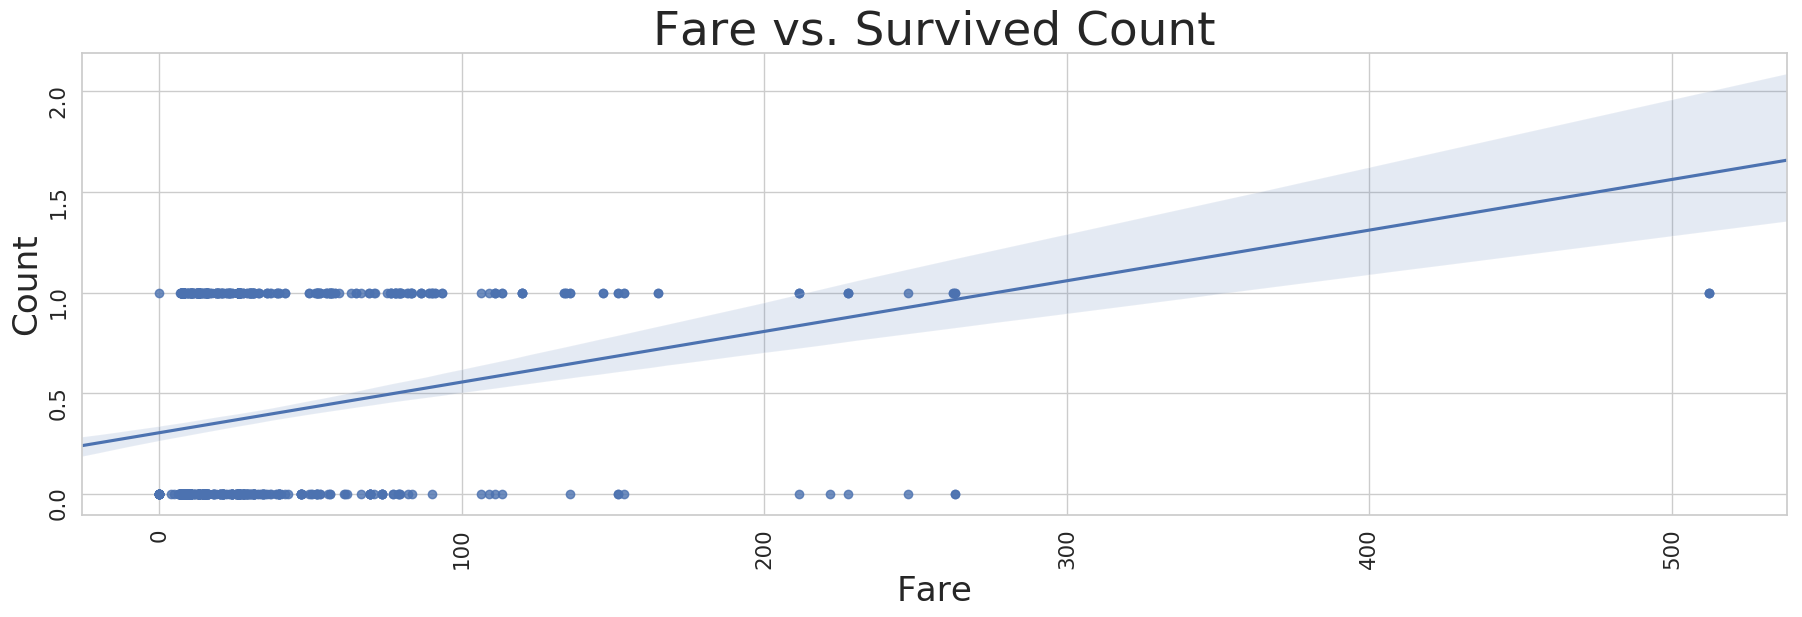

In [17]:
col = "Fare"
target = "Survived"
y_label = "Count"


nrows = 6
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.6
titlesize = labelsize*2.2

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

ax = sns.distplot(df[col])
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize, rotation=90)
plt.show()


ax = sns.lineplot(x=col2, y=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col2+" vs. "+ target+" Line Plot", fontsize=titlesize)
ax.set_xlabel(col2, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)
plt.show()

ax = sns.regplot(x=col, y=target, data=df)
ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title(col+" vs. "+ target+" Count", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize, rotation=90)
plt.show()

# 4. Preprocessing

In [18]:
def transform(x):
    if x==0: return 0
    else: return 1
    
def prep(train, title=None, ticket=None):
    m_embarked = {"S": 0, "Q": 1, "C": 2}

    train["NameLen"] = train["Name"].apply(lambda x: len(x))
    train["NameCount"] = train["Name"].apply(lambda x:len(x.split(" ")))
    train["Title"] = train["Name"].apply(lambda x:x.split(" ")[1])
    
    if not title:
        title = {}
    for item, value in enumerate(set(train["Title"])):
        title[value] = item

    train["Title"] = train["Title"].map(title)


    train['FamilySize'] = train ['SibSp'] + train['Parch'] + 1

    train['IsAlone'] = 1 
    train['IsAlone'].loc[train['FamilySize'] > 1] = 0 

    
    train["Sex"] = train["Sex"].apply(lambda x: 0 if x=="male" else 1)
    
    train['Age'].fillna(train['Age'].median(), inplace = True)
    train['Age'] = train['Age'].apply(lambda x: int(x/5))
    
#     train['AgeBin'] = pd.cut(train['Age'].astype(int), 5)
    
#     if age_bin==None:
#         age_bin = {}
#         for item, value in enumerate(set(train['AgeBin'])):
#             age_bin[value] = item
    
       
#     train['AgeBin'] = train['AgeBin'].map(age_bin)
    
    train['SibSp'] = train['SibSp'].apply(lambda x: transform(x))
    train['Parch'] = train['Parch'].apply(lambda x: transform(x))
    
    train['Fare'].fillna(train['Fare'].median(), inplace = True)
#     train['FareBin'] = pd.qcut(train['Fare'], 4)
    
#     if not fare_bin:
#         fare_bin = {}
#         for item, value in enumerate(set(train['FareBin']), 1):
#             fare_bin[value] = item
#     train['FareBin'] = train['FareBin'].map(fare_bin)
    
    emb = train['Embarked'].mode()[0]
    train['Embarked'] = train['Embarked'].apply(lambda x: x if x in m_embarked else emb)
    train['Embarked'] = train['Embarked'].map(m_embarked)
    
    
    train["TicketType"] = train["Ticket"].apply(lambda x: x.split(" ")[0])
    train["TicketType"] = train["TicketType"].apply(lambda x: 0 if x.isdigit() else re.sub(r"[^a-zA-Z]", "", x.split("/")[0]))
    
    if not ticket:
        ticket = {}
    for item, value in enumerate(set(train["TicketType"])):
        ticket[value] = item
    train["TicketType"] = train["TicketType"].map(ticket)
    
    
    if title and ticket:
        return train, title, ticket
    else:
        return train


In [19]:
train, title, ticket = prep(train)
test, title, ticket = prep(test, title=title, ticket=ticket)

/opt/conda/lib/python3.6/site-packages/pandas/core/indexing.py:189: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._setitem_with_indexer(indexer, value)


In [20]:
all_columns = ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked','FamilySize', 'IsAlone']
columns = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'NameLen', 'NameCount', 'Title', 'FamilySize', 'IsAlone', 'TicketType']
drop_cols = ["PassengerId", "Survived", "Name", "Ticket", "Cabin"]
target_col = 'Survived'

# categorical_data = train.select_dtypes("object_")
# numerical_data = train.select_dtypes("number")


/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


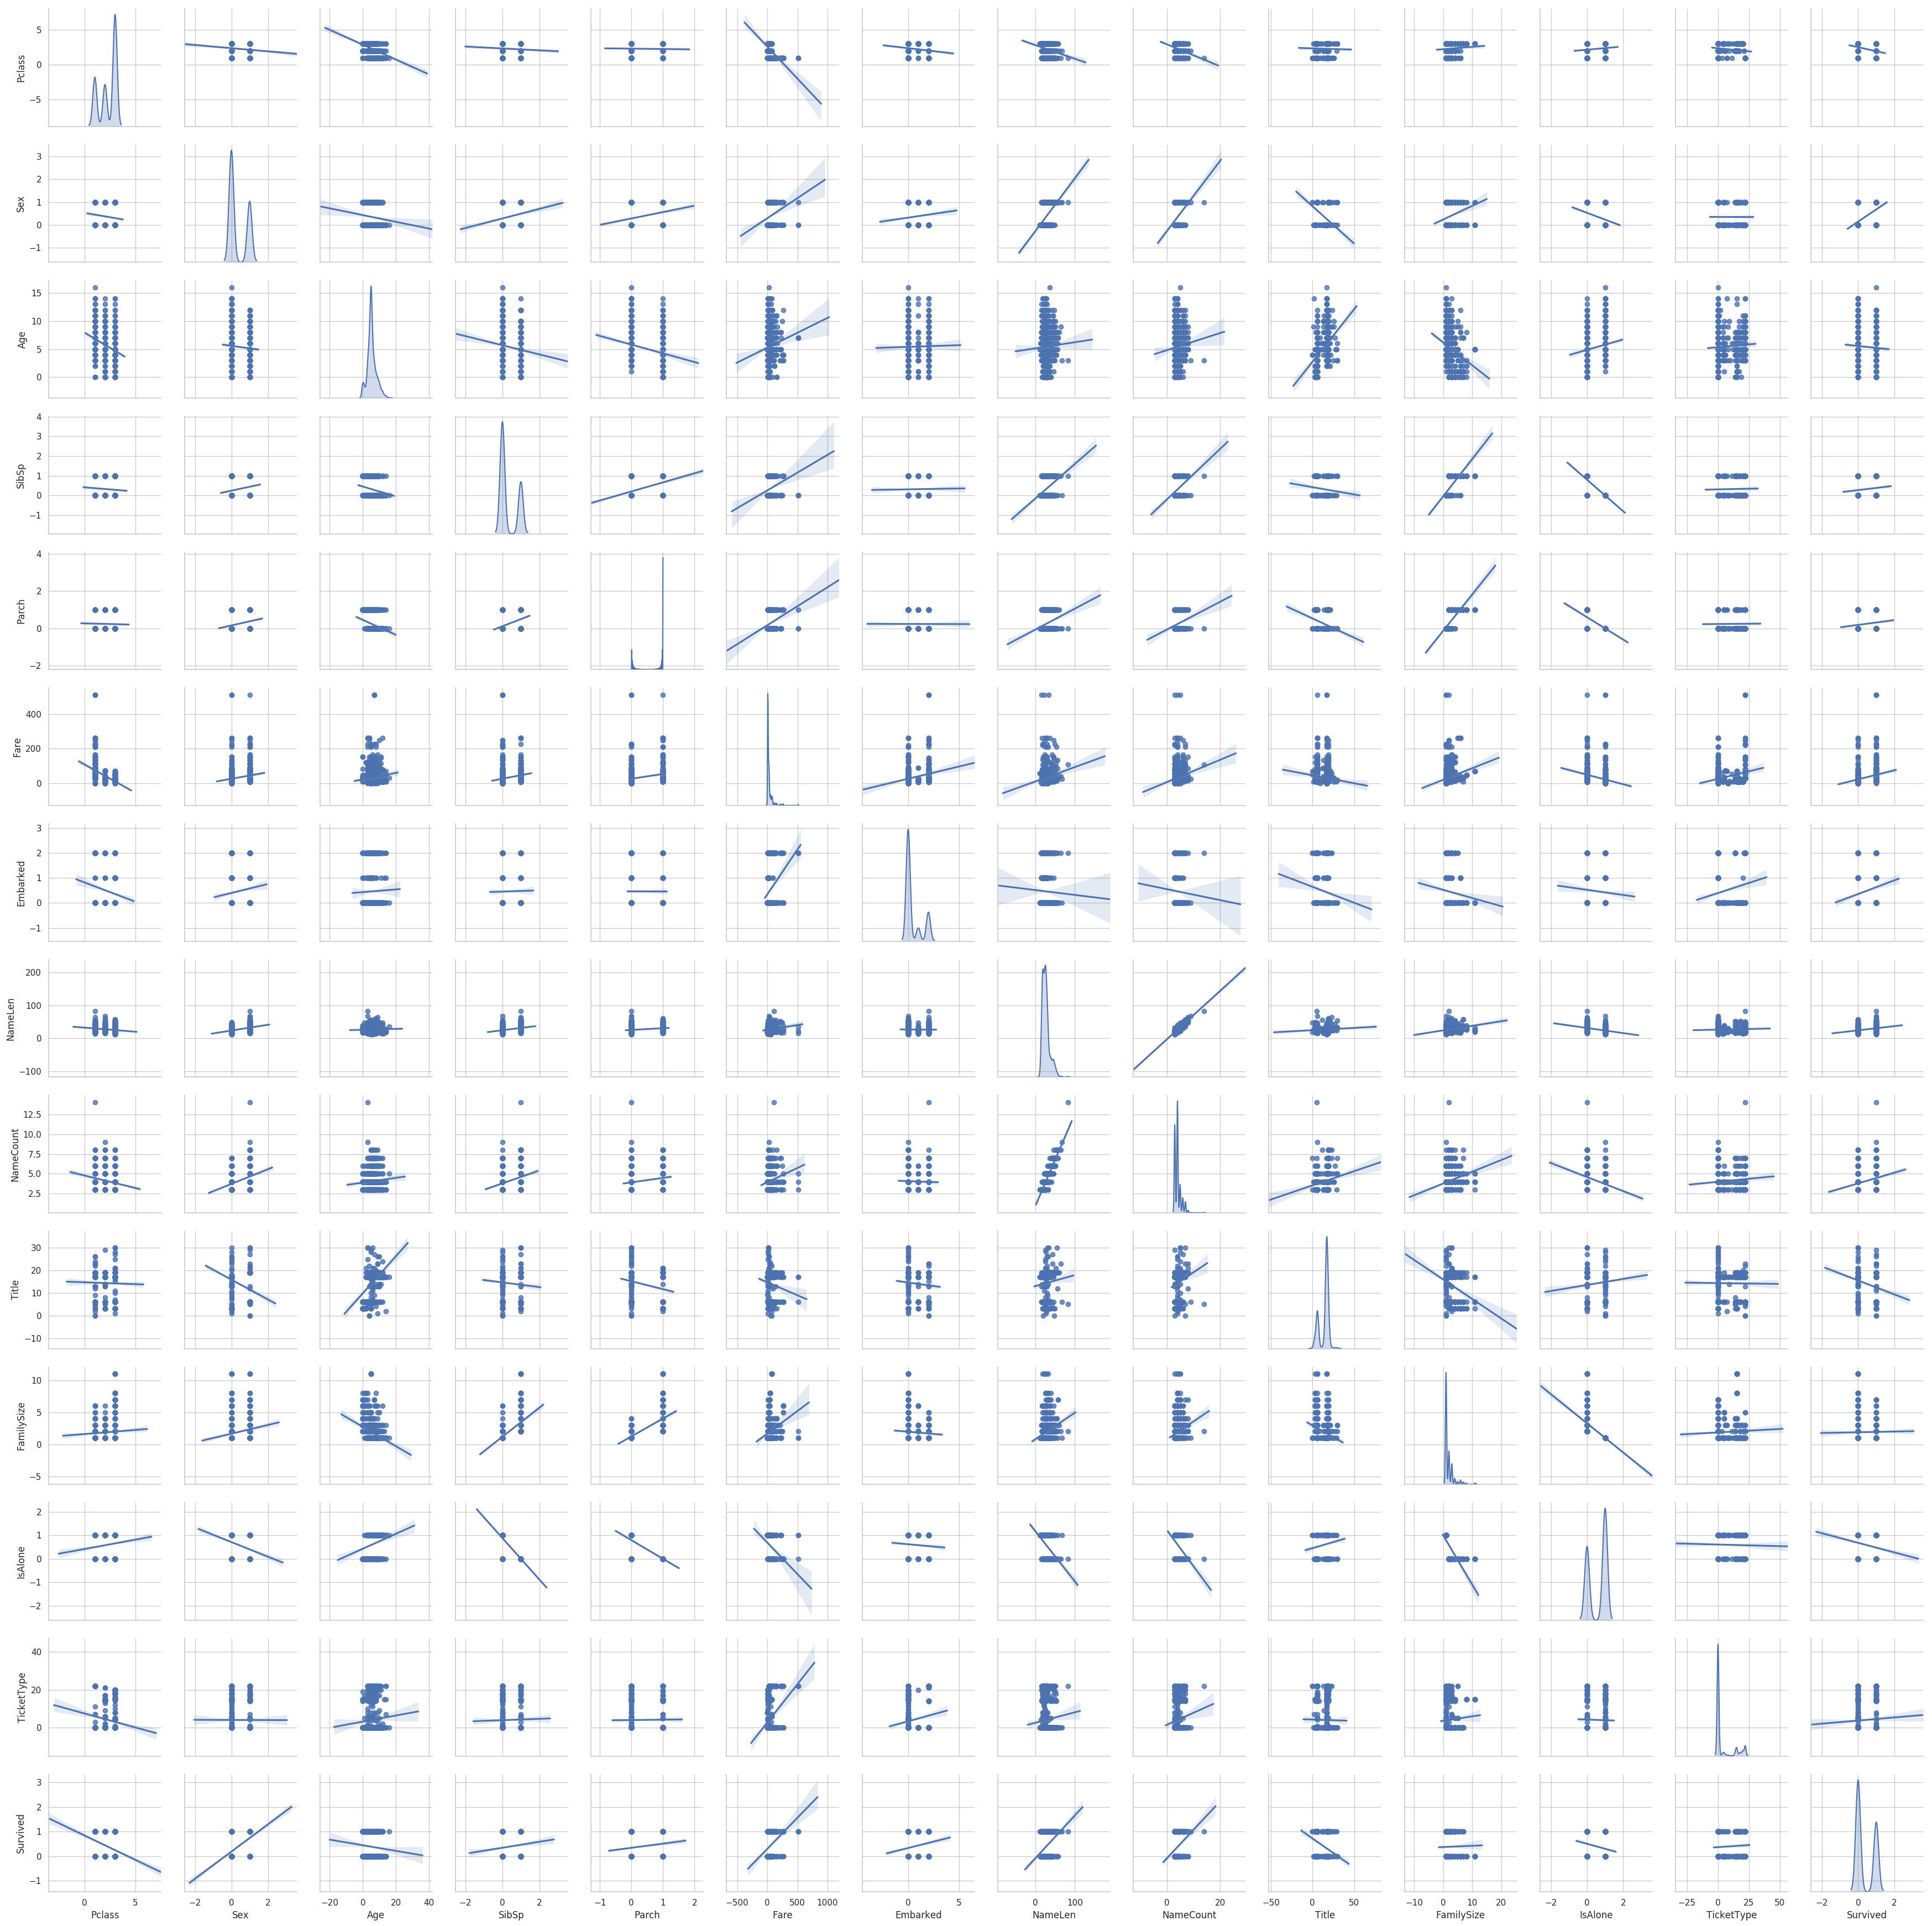

In [21]:
cols = [columns+[target_col]][0]
d = train[cols]
sns.pairplot(d, kind='reg', diag_kind='kde', dropna=True)

In [22]:
# g = sns.PairGrid(
#     d, 
#     diag_sharey=True, 
#     height=2.5, 
#     aspect=1, 
#     despine=True, 
#     dropna=False)
# g = g.map(plt.scatter)
# g.map_diag(plt.hist)
# g.map_offdiag(plt.scatter);

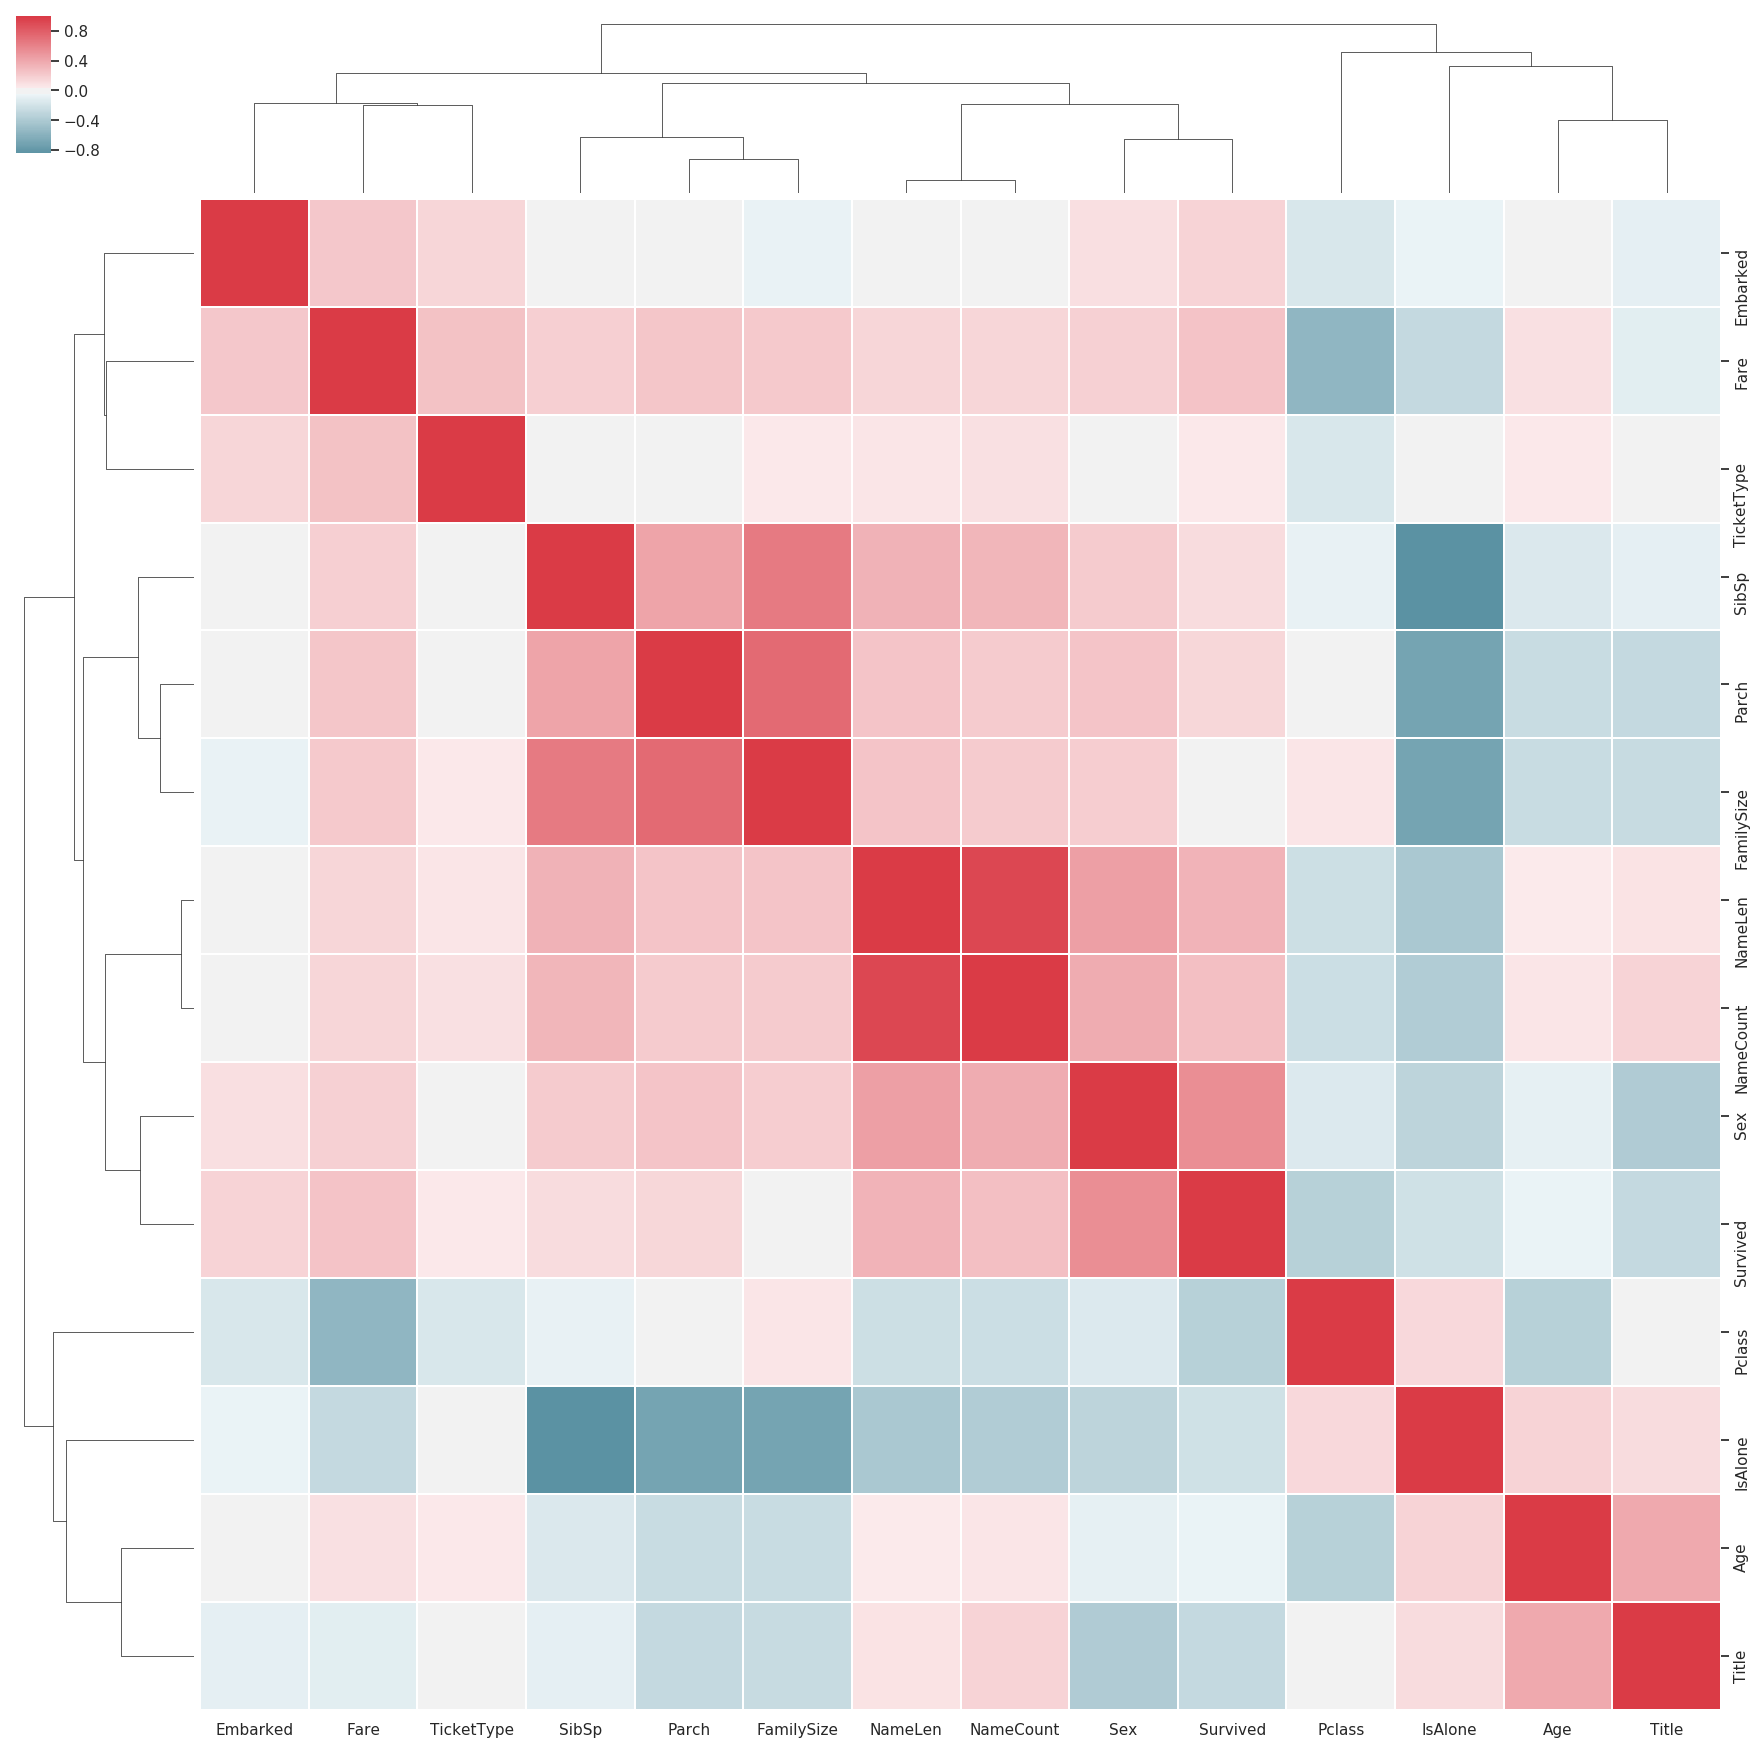

In [23]:
sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

nrows = 22
ncols = 22

cmap = sns.diverging_palette(h_neg=220, h_pos=10, s=75, l=50, sep=10, n=len(columns), center='light', as_cmap=True)

sns.clustermap(d.corr(),  
               figsize=(ncols, nrows), 
               center=0,
               cmap=cmap,
               linewidths=.75)

plt.show()

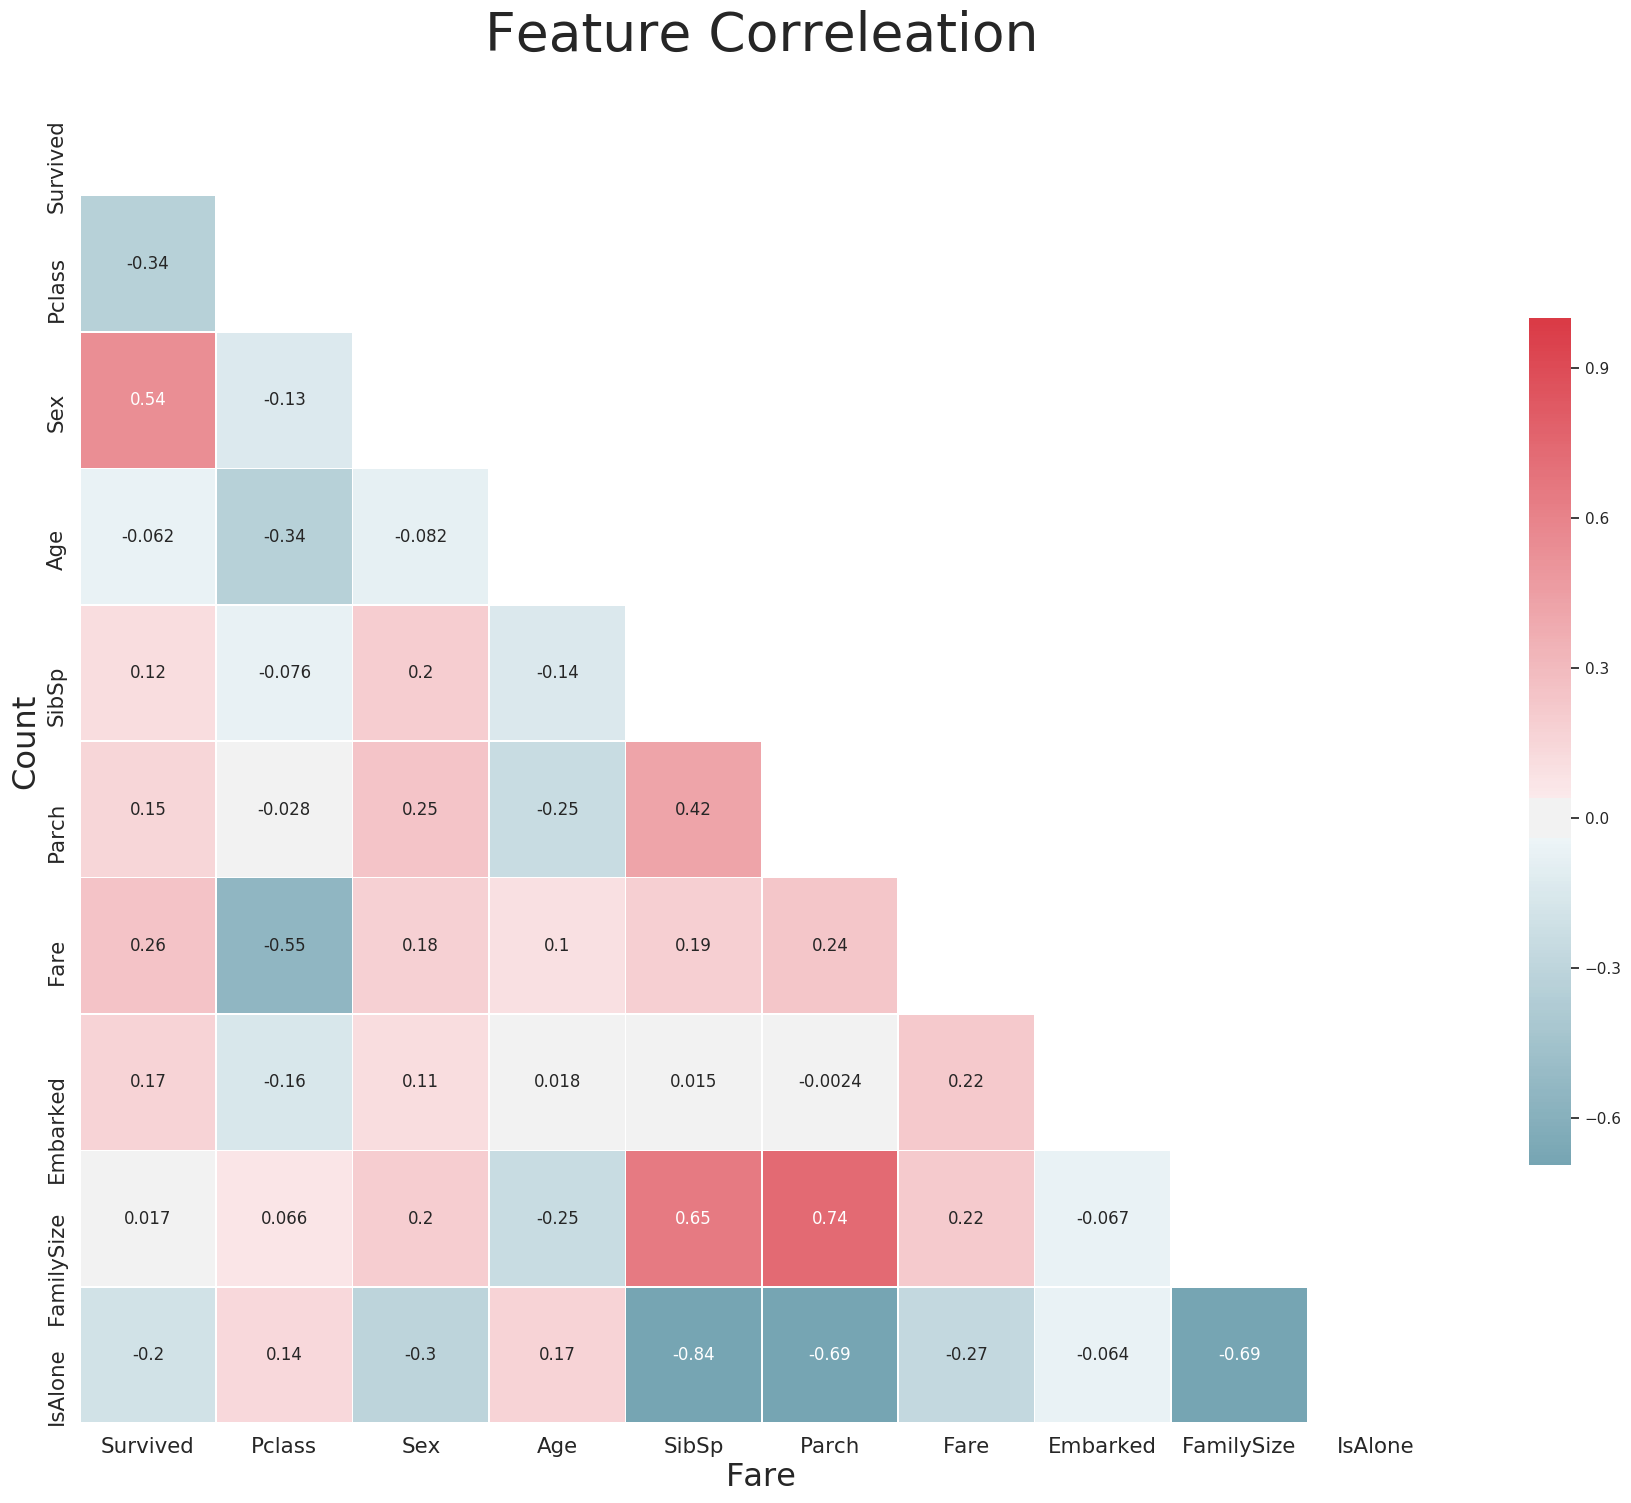

In [24]:
nrows = 22
ncols = 22

labelsize = ncols*.7
fontsize = labelsize*1.5
titlesize = labelsize*2.5

sns.reset_defaults()
sns.set(style="whitegrid")
sns.set_context("notebook")

d =train[all_columns]

# Compute the correlation matrix
corr = d.corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(ncols, nrows))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(h_neg=220, h_pos=10, s=75, l=50, sep=10, n=len(columns), center='light', as_cmap=True)

ax = sns.heatmap(
    corr,
    cmap=cmap,
    center=0,
    robust=True,
    annot=True,
    linewidths=0.5,
    linecolor='white',
    cbar=True,
    cbar_kws={"shrink": .5},
    square=True,
    mask=mask)

ax.figure.set_size_inches(ncols, nrows)
ax.axes.set_title("Feature Correleation", fontsize=titlesize)
ax.set_xlabel(col, fontsize=fontsize)
ax.set_ylabel(y_label, fontsize=fontsize)
ax.tick_params(labelsize=labelsize)

In [25]:
def print_performance(model, X_test, y_test, class_names):
    preds = model.predict(X_test)

    # accuracy_score = metrics.accuracy_score(y_test, preds)
    # auc = metrics.auc(y_test, preds)
    # average_precision_score = metrics.average_precision_score(y_test, preds)
    classification_report = metrics.classification_report(y_test, preds)
    # cohen_kappa_score = metrics.cohen_kappa_score(y_test, preds)
    confusion_matrix = metrics.confusion_matrix(y_test, preds)
    f1_score_ = metrics.f1_score(y_test, preds, average="weighted")
    # precision_recall_curve = metrics.precision_recall_curve(y_test, preds)
    # precision_score = metrics.precision_score(y_test, preds, average="weighted")
    # recall_score = metrics.recall_score(y_test, preds, average="weighted")
    # roc_auc_score = metrics.roc_auc_score(y_test, preds, average="weighted")
    # roc_curve = metrics.roc_curve(y_test, preds)
    
    print("-"*55)
    print("Performance")
    print("-"*55)
    print("{} : {:.4f} ".format("Accuracy Score                  ", accuracy_score))
    # print("{} : {:.4f} ".format("AUC                             ", auc))
    # print("{} : {:.4f} ".format("Average Precision Score         ", average_precision_score))
#     print("{} : {:.4f} ".format("Classification Report           ", classification_report))
#     print("{} : {:.4f} ".format("Confusion Matrix                ", confusion_matrix))
    print("{} : {:.4f} ".format("F1 Score                        ", f1_score_))
    # print("{} : {:.4f} ".format("Precision Recall Curve          ", precision_recall_curve))
    print("{} : {:.4f} ".format("Precision Score                 ", precision_score))
    print("{} : {:.4f} ".format("Recall Score                    ", recall_score))
    # print("{} : {:.4f} ".format("Roc Auc Score                   ", roc_auc_score))
    # print("{} : {:.4f} ".format("Roc Curve                       ", roc_curve))
    print(classification_report)
    
    print("-"*55)
    print("\n\n")
    

    np.set_printoptions(precision=2)

    # Plot non-normalized confusion matrix
    plt.subplot(121)
    plot_confusion_matrix(confusion_matrix, classes=class_names, title='Confusion matrix, without normalization')

    # Plot normalized confusion matrix
    plt.subplot(122)
    plot_confusion_matrix(confusion_matrix, classes=class_names, normalize=True, title='Normalized confusion matrix')

    plt.show()
    
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    
    
def print_performance_grid(clf):
    # print("*"*100)
    # print("{}{}{}".format("*"*40,"Performance", "*"*40))
    print("{}".format("Performance"))
    print("*"*100)
    print("Score            : {}".format(clf.score(X, y)))
    print("Best Estimator   : {}".format(clf.best_estimator_))
    print("Best Score       : {}".format(clf.best_score_))
    print("Best Params      : {}".format(clf.best_params_))
    print("Best Index       : {}".format(clf.best_index_))
    print("Scorer           : {}".format(clf.scorer_))
    print("Refit Time       : {}".format(clf.refit_time_))
    # print("CV Results       : {}".format(clf.cv_results_))

    params = clf.get_params()
    best_estimator = clf.best_estimator_
    cv_results = clf.cv_results_
    
    return params, best_estimator, cv_results

# 5. Training and Evaluation

In [26]:
train_features = train[columns]
test_features = test[columns]


target = train[target_col]

In [27]:
train_features.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,NameLen,NameCount,Title,FamilySize,IsAlone,TicketType
0,3,0,4,1,0,7.2500,0,23,4,17,2,0,20
1,1,1,7,1,0,71.2833,2,51,7,19,2,0,22
2,3,1,5,0,0,7.9250,0,22,3,6,1,1,18
3,1,1,7,1,0,53.1000,0,44,7,19,2,0,0
4,3,0,7,0,0,8.0500,0,24,4,17,1,1,0


In [28]:
train_features = train_features.values
test_features = test_features.values

target = target.values

In [29]:
# train_features = train_features.fillna(0)

# test_features = test_features.fillna(0)

scaler = StandardScaler()

train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

In [30]:
train_features[0], test_features[0]

(array([ 0.82737724, -0.73769513, -0.54054821,  1.46574551, -0.56049915,
        -0.50244517, -0.58595414, -0.42745127, -0.05947423,  0.47993439,
         0.05915988, -1.2316449 ,  2.11170391]),
 array([ 0.82737724, -0.73769513,  0.21554042, -0.68224668, -0.56049915,
        -0.49078316,  0.67817453, -1.1820546 , -0.91417654, -2.40940037,
        -0.56097483,  0.81192233, -0.53498083]))

In [31]:
X = train_features
y = target

In [32]:
# # SVC
# estimator = svm.SVC(class_weight='balanced')

# kernel = ('linear', 'poly', 'rbf', 'sigmoid', 'precomputed')
# degree = np.arange(1, 10, 1)
# C = np.array([np.arange(0.01, 0.1, 0.01), np.arange(0.1, 1, 0.1), np.arange(1, 10, 1)]).flatten()
# gamma = np.array([np.arange(0.01, 0.1, 0.01), np.arange(0.1, 1, 0.1), np.arange(1, 10, 1)]).flatten()


# param_grid = {
#     'kernel': ['linear'], 
#     'C': C,
#     'gamma': gamma
# }

# # RandomForestClassifier
# # estimator = RandomForestClassifier(n_estimators=100, class_weight="balanced")

# # param_grid = {"n_estimators": np.arange(1, 100, 1)}


# cv = 3
# verbose = 1

# grid_clf = GridSearchCV(estimator=estimator,param_grid=param_grid, n_jobs=-1, cv=cv, verbose=verbose)

# grid_clf.fit(X, y)

In [33]:
# params, best_estimator, cv_results = print_performance_grid(grid_clf)

In [34]:
clf = RandomForestClassifier(n_estimators=1000, class_weight="balanced")
# clf = SVC(C=0.04, gamma=0.01, kernel='linear', class_weight="balanced")

cv = 3
verbose = 1
scores = cross_val_score(clf, X, y, cv=cv, verbose=verbose)

print(scores)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[0.7979798  0.83838384 0.81481481]


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.7s finished


# 6. Inference/ Prediction

In [35]:
clf = RandomForestClassifier(n_estimators=100, class_weight="balanced")
clf = clf.fit(X, y)
preds = clf.predict(test_features)

In [36]:
submission_csv = "submission.csv"

df_test = pd.DataFrame({'PassengerId':submission['PassengerId'], 'Survived':preds})

df_test.to_csv(submission_csv, index=False)
df_test.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
